
╔══════════════════════════════════════════════════════════════════╗
║       🚀 HYBRID CNN + PatchTST v3 (MPS OPTIMIZED)                ║
╠══════════════════════════════════════════════════════════════════╣
║  Device:           mps                                         ║
║  Batch Size:       64 (optimal for MPS)                       ║
║  Learning Rate:    0.0003 (with warmup)                       ║
║  Warmup:           5 epochs                                    ║
║  Save Logic:       BestVal + Sniper Alpha ✓                      ║
╚══════════════════════════════════════════════════════════════════╝

📊 Loading data with TEMPORAL SPLIT (NO LEAKAGE!)...
   📁 Found 42 files
   Train: 91,087 | Val: 16,095 | Test: 22,655
   Features: 45
   Balance: Train UP=52.3% | Val UP=54.2% | Test UP=52.4%
🔧 Model: 53,229 parameters

═══════════════════════════════════════════════════════════════════════════════════════════════
🚀 PHASE 1: TRAINING
════════════════════════════════════════════════════

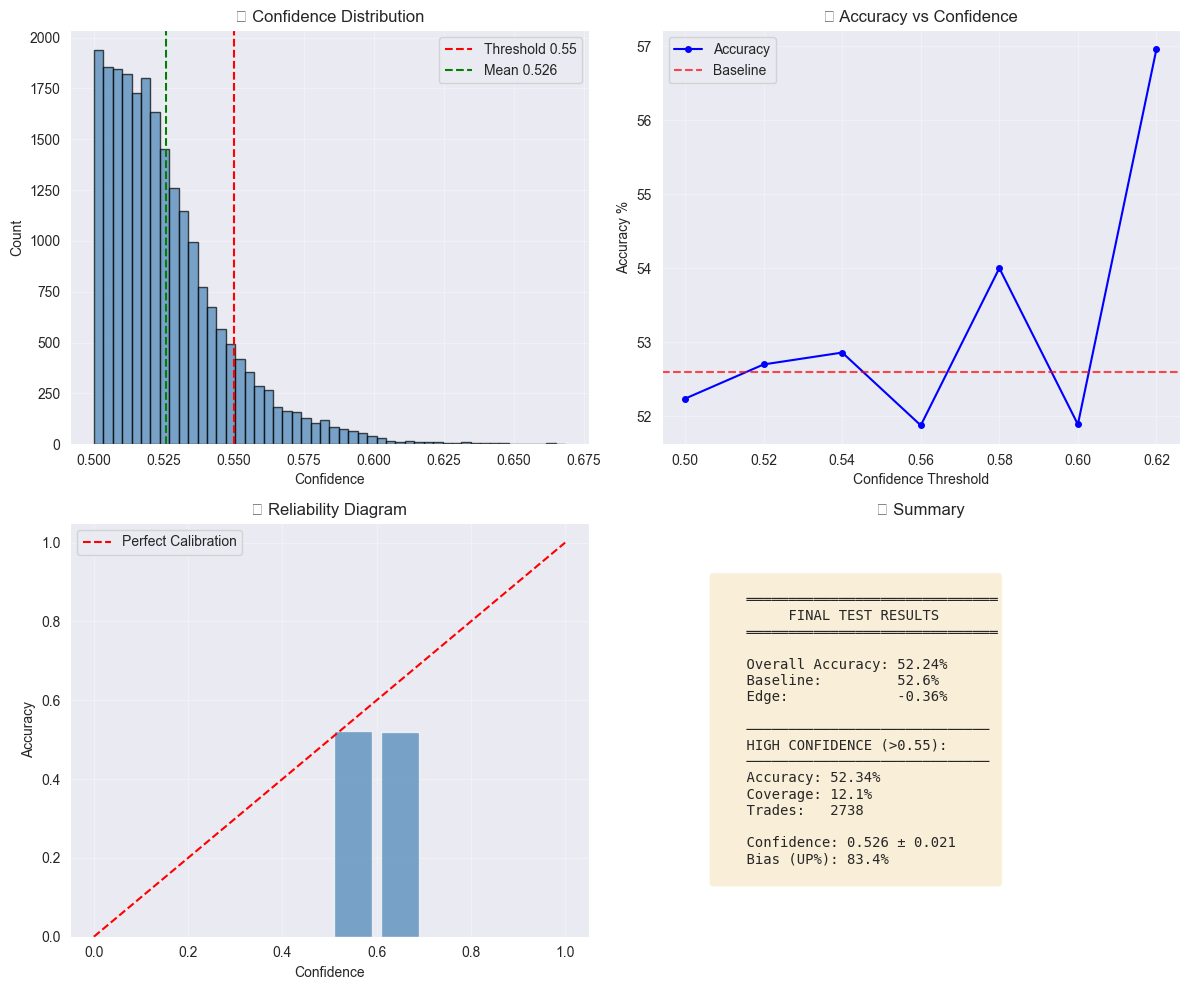

💾 Saved: cnn_patch_models_v3/results.png

✅ DONE!
📁 All models saved in: cnn_patch_models_v3/


In [29]:
"""
🚀 PRODUCTION Hybrid CNN + PatchTST v3
======================================
✓ MPS OPTIMIZED (Apple Silicon)
✓ ТВОЯ ЛОГИКА СОХРАНЕНИЯ (BestVal + Sniper Alpha)
✓ Fixed training collapse
✓ Warmup + proper LR
"""

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ══════════════════════════════════════════════════════════════
#                    MPS-OPTIMIZED CONFIG
# ══════════════════════════════════════════════════════════════
class Config:
    DATA_DIR = "US Stock Market Data/fundamentals"
    SAVE_DIR = "cnn_patch_models_v3"

    # Sequence params
    SEQ_LEN = 30
    PATCH_LEN = 6
    STRIDE = 3
    NORM_WINDOW = 60

    # ═══ MODEL — Lighter for MPS ═══
    D_MODEL = 24
    N_HEADS = 4
    N_LAYERS = 2
    DROPOUT = 0.25
    D_FUSE = 48

    # ═══ TRAINING — Fixed for MPS ═══
    BATCH_SIZE = 64
    EPOCHS = 80
    LR = 3e-4
    WEIGHT_DECAY = 5e-3
    PATIENCE = 25
    WARMUP_EPOCHS = 5

    VAL_RATIO = 0.15
    INIT_TEMPERATURE = 1.5

    DEVICE = torch.device('mps' if torch.backends.mps.is_available() else
                          'cuda' if torch.cuda.is_available() else 'cpu')

cfg = Config()
cfg.N_PATCHES = (cfg.SEQ_LEN - cfg.PATCH_LEN) // cfg.STRIDE + 1

os.makedirs(cfg.SAVE_DIR, exist_ok=True)

print(f"""
╔══════════════════════════════════════════════════════════════════╗
║       🚀 HYBRID CNN + PatchTST v3 (MPS OPTIMIZED)                ║
╠══════════════════════════════════════════════════════════════════╣
║  Device:           {str(cfg.DEVICE):<20}                        ║
║  Batch Size:       {cfg.BATCH_SIZE} (optimal for MPS)                       ║
║  Learning Rate:    {cfg.LR} (with warmup)                       ║
║  Warmup:           {cfg.WARMUP_EPOCHS} epochs                                    ║
║  Save Logic:       BestVal + Sniper Alpha ✓                      ║
╚══════════════════════════════════════════════════════════════════╝
""")


# ══════════════════════════════════════════════════════════════
#                    LIGHTWEIGHT MODEL
# ══════════════════════════════════════════════════════════════

class LightPatchTST(nn.Module):
    """Облегчённый PatchTST для MPS"""

    def __init__(self, n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout):
        super().__init__()
        self.n_ch = n_ch
        self.patch_len = patch_len
        self.stride = stride
        self.n_patches = (seq_len - patch_len) // stride + 1
        self.d_model = d_model

        self.norm = nn.BatchNorm1d(n_ch)

        self.patch_proj = nn.Sequential(
            nn.Linear(patch_len, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model)
        )

        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.agg = nn.Sequential(
            nn.Linear(n_ch * d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.out_dim = d_model

    def forward(self, x):
        B, L, C = x.shape
        x = self.norm(x.transpose(1, 2))
        patches = x.unfold(2, self.patch_len, self.stride)
        patches = patches.reshape(B * C, self.n_patches, self.patch_len)
        patches = self.patch_proj(patches) + self.pos_embed
        patches = self.transformer(patches)
        channel_emb = patches.mean(dim=1).reshape(B, C * self.d_model)
        return self.agg(channel_emb)


class LightCNN(nn.Module):
    """Облегчённый CNN"""

    def __init__(self, n_ch, d_out, dropout):
        super().__init__()
        h = 24

        self.conv = nn.Sequential(
            nn.Conv1d(n_ch, h, 3, padding=1),
            nn.BatchNorm1d(h),
            nn.GELU(),
            nn.Conv1d(h, h, 5, padding=2),
            nn.BatchNorm1d(h),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.proj = nn.Linear(h, d_out)
        self.out_dim = d_out

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.mean(dim=2)
        return self.proj(x)


class LightGatedFusion(nn.Module):
    """Simplified fusion"""

    def __init__(self, d1, d2, d_out):
        super().__init__()
        self.proj = nn.Linear(d1 + d2, d_out)
        self.gate = nn.Linear(d1 + d2, d_out)
        self.norm = nn.LayerNorm(d_out)

    def forward(self, x1, x2):
        combined = torch.cat([x1, x2], dim=-1)
        g = torch.sigmoid(self.gate(combined))
        h = self.proj(combined)
        return self.norm(g * h)


class HybridModelV3(nn.Module):
    """Optimized Hybrid for MPS"""

    def __init__(self, n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout, d_fuse, init_temp=1.5):
        super().__init__()

        self.cnn = LightCNN(n_ch, d_fuse, dropout)
        self.tst = LightPatchTST(n_ch, seq_len, patch_len, stride, d_model, n_heads, n_layers, dropout)
        self.fusion = LightGatedFusion(self.cnn.out_dim, self.tst.out_dim, d_fuse)

        self.head = nn.Sequential(
            nn.Linear(d_fuse, d_fuse),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_fuse, 2)
        )

        self.temperature = nn.Parameter(torch.tensor(init_temp))
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')

    def forward(self, x):
        cnn_out = self.cnn(x)
        tst_out = self.tst(x)
        fused = self.fusion(cnn_out, tst_out)
        logits = self.head(fused)

        probs = F.softmax(logits / self.temperature, dim=-1)
        confidence = probs.max(dim=-1).values

        return logits, confidence


# ══════════════════════════════════════════════════════════════
#                    DATA PIPELINE
# ══════════════════════════════════════════════════════════════

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def rolling_normalize(data, window):
    """Rolling Z-score — NO DATA LEAKAGE"""
    result = np.zeros_like(data)
    for i in range(len(data)):
        start = max(0, i - window)
        end = i + 1
        if end - start < 5:
            result[i] = 0
        else:
            window_data = data[start:end]
            mean = window_data.mean(axis=0)
            std = window_data.std(axis=0) + 1e-8
            result[i] = (data[i] - mean) / std
    return np.clip(result, -5, 5)


def create_features(df):
    """Feature engineering"""
    df = df.copy()

    for w in [1, 5, 10, 20]:
        df[f'ret_{w}'] = df['close'].pct_change(w)

    df['vol_5'] = df['ret_1'].rolling(5).std()
    df['vol_20'] = df['ret_1'].rolling(20).std()

    for w in [10, 20]:
        ma = df['close'].rolling(w).mean()
        df[f'trend_{w}'] = (df['close'] - ma) / (ma + 1e-10)

    delta = df['close'].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    df['rsi'] = 100 - 100 / (1 + gain / (loss + 1e-10))

    for col in ['pe_ratio', 'pb_ratio', 'ps_ratio']:
        if col in df.columns:
            df[f'{col}_z'] = (df[col] - df[col].rolling(20).mean()) / (df[col].rolling(20).std() + 1e-10)

    for col in ['return_on_equity', 'return_on_assets']:
        if col in df.columns:
            df[f'{col}_chg'] = df[col].diff()

    return df


def load_data_temporal_split(folder, seq_len, norm_window, val_ratio):
    """Load with temporal split"""
    train_X, train_y, val_X, val_y = [], [], [], []
    files = [f for f in os.listdir(folder) if f.endswith('.csv')]
    print(f"   📁 Found {len(files)} files")

    for file in files:
        try:
            df = pd.read_csv(os.path.join(folder, file))
            df.columns = df.columns.str.lower().str.strip()

            if 'close' not in df.columns:
                continue
            if 'date' in df.columns:
                df = df.sort_values('date').reset_index(drop=True)

            df = create_features(df)
            df['target'] = (df['close'].shift(-1) > df['close']).astype(int)
            df = df.replace([np.inf, -np.inf], np.nan).dropna()

            if len(df) < seq_len + norm_window + 20:
                continue

            exclude = ['date', 'close', 'target', 'open', 'high', 'low']
            cols = [c for c in df.columns if c not in exclude
                   and df[c].dtype in ['float64', 'int64', 'float32']]

            raw = df[cols].values
            features = rolling_normalize(raw, norm_window)
            targets = df['target'].values

            samples_X, samples_y = [], []
            for i in range(norm_window, len(features) - seq_len):
                samples_X.append(features[i:i + seq_len])
                samples_y.append(targets[i + seq_len - 1])

            if len(samples_X) < 20:
                continue

            split_idx = int(len(samples_X) * (1 - val_ratio))
            train_X.extend(samples_X[:split_idx])
            train_y.extend(samples_y[:split_idx])
            val_X.extend(samples_X[split_idx:])
            val_y.extend(samples_y[split_idx:])

        except:
            continue

    return (np.array(train_X, dtype=np.float32), np.array(train_y, dtype=np.int64),
            np.array(val_X, dtype=np.float32), np.array(val_y, dtype=np.int64))


def load_test_data(folder, seq_len, norm_window):
    """Load test data"""
    all_X, all_y = [], []
    files = [f for f in os.listdir(folder) if f.endswith('.csv')]

    for file in files:
        try:
            df = pd.read_csv(os.path.join(folder, file))
            df.columns = df.columns.str.lower().str.strip()

            if 'close' not in df.columns:
                continue
            if 'date' in df.columns:
                df = df.sort_values('date').reset_index(drop=True)

            df = create_features(df)
            df['target'] = (df['close'].shift(-1) > df['close']).astype(int)
            df = df.replace([np.inf, -np.inf], np.nan).dropna()

            if len(df) < seq_len + norm_window:
                continue

            exclude = ['date', 'close', 'target', 'open', 'high', 'low']
            cols = [c for c in df.columns if c not in exclude
                   and df[c].dtype in ['float64', 'int64', 'float32']]

            raw = df[cols].values
            features = rolling_normalize(raw, norm_window)
            targets = df['target'].values

            for i in range(norm_window, len(features) - seq_len):
                all_X.append(features[i:i + seq_len])
                all_y.append(targets[i + seq_len - 1])

        except:
            continue

    return np.array(all_X, dtype=np.float32), np.array(all_y, dtype=np.int64)


# ══════════════════════════════════════════════════════════════
#                    TRAINING FUNCTIONS
# ══════════════════════════════════════════════════════════════

def get_lr_with_warmup(epoch, warmup_epochs, base_lr, total_epochs):
    """Learning rate with warmup"""
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    else:
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return base_lr * 0.5 * (1 + np.cos(np.pi * progress))


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits, _ = model(X)
        loss = criterion(logits, y)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        preds = logits.argmax(dim=-1)
        total_loss += loss.item() * len(y)
        correct += (preds == y).sum().item()
        total += len(y)

    return total_loss / total, correct / total * 100


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    P, T, C = [], [], []

    for X, y in loader:
        logits, conf = model(X.to(device))
        P.extend(logits.argmax(dim=-1).cpu().numpy())
        T.extend(y.numpy())
        C.extend(conf.cpu().numpy())

    P, T, C = map(np.array, [P, T, C])
    acc = (P == T).mean() * 100

    results = {
        'acc': acc,
        'conf_mean': C.mean(),
        'conf_std': C.std(),
        'bias': (P == 1).mean() * 100,
        'P': P, 'T': T, 'C': C
    }

    for thr in [0.52, 0.55, 0.58, 0.60, 0.65, 0.70]:
        mask = C > thr
        if mask.sum() > 30:
            results[f'acc@{thr}'] = (P[mask] == T[mask]).mean() * 100
            results[f'cov@{thr}'] = mask.mean() * 100
        else:
            results[f'acc@{thr}'] = 0
            results[f'cov@{thr}'] = 0

    return results


def calibrate_temperature(model, loader, device):
    """Calibrate temperature on validation"""
    model.eval()

    all_logits, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            logits, _ = model(X.to(device))
            all_logits.append(logits)
            all_labels.append(y.to(device))

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)

    best_temp = 1.0
    best_loss = float('inf')

    for temp in np.arange(0.5, 3.0, 0.1):
        loss = F.cross_entropy(all_logits / temp, all_labels).item()
        if loss < best_loss:
            best_loss = loss
            best_temp = temp

    model.temperature.data = torch.tensor(best_temp)
    return best_temp


def save_checkpoint(model, epoch, val_acc, hiconf_acc, hiconf_cov, save_dir):
    """Сохранение чекпоинта — ТВОЯ ЛОГИКА"""
    filepath = os.path.join(save_dir, f'model_ep{epoch:03d}_val{val_acc:.2f}_hc{hiconf_acc:.2f}.pt')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'val_acc': val_acc,
        'hiconf_acc': hiconf_acc,
        'hiconf_cov': hiconf_cov,
        'temperature': model.temperature.item(),
        'timestamp': datetime.now().isoformat()
    }, filepath)
    return filepath


def plot_results(m, save_path='results.png'):
    """Графики результатов"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Confidence Distribution
    ax = axes[0, 0]
    ax.hist(m['C'], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.axvline(x=0.55, color='red', linestyle='--', label='Threshold 0.55')
    ax.axvline(x=m['C'].mean(), color='green', linestyle='--', label=f'Mean {m["C"].mean():.3f}')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Count')
    ax.set_title('📊 Confidence Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Accuracy vs Threshold
    ax = axes[0, 1]
    thresholds = np.arange(0.50, 0.75, 0.02)
    accs = []
    for thr in thresholds:
        mask = m['C'] > thr
        if mask.sum() > 30:
            accs.append((m['P'][mask] == m['T'][mask]).mean() * 100)
        else:
            accs.append(np.nan)

    ax.plot(thresholds, accs, 'b-o', label='Accuracy', markersize=4)
    ax.axhline(y=52.6, color='red', linestyle='--', alpha=0.7, label='Baseline')
    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Accuracy %')
    ax.set_title('🎯 Accuracy vs Confidence')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3. Reliability Diagram
    ax = axes[1, 0]
    n_bins = 10
    for i in range(n_bins):
        low, high = i / n_bins, (i + 1) / n_bins
        mask = (m['C'] >= low) & (m['C'] < high)
        if mask.sum() > 0:
            bin_acc = (m['P'][mask] == m['T'][mask]).mean()
            ax.bar(low + 0.05, bin_acc, width=0.08, alpha=0.7, color='steelblue')

    ax.plot([0, 1], [0, 1], 'r--', label='Perfect Calibration')
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Accuracy')
    ax.set_title('📏 Reliability Diagram')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 4. Summary
    ax = axes[1, 1]
    hc_mask = m['C'] > 0.55
    hc_acc = (m['P'][hc_mask] == m['T'][hc_mask]).mean() * 100 if hc_mask.sum() > 0 else 0

    text = f"""
    ══════════════════════════════
         FINAL TEST RESULTS
    ══════════════════════════════

    Overall Accuracy: {m['acc']:.2f}%
    Baseline:         52.6%
    Edge:             {m['acc'] - 52.6:+.2f}%

    ─────────────────────────────
    HIGH CONFIDENCE (>0.55):
    ─────────────────────────────
    Accuracy: {hc_acc:.2f}%
    Coverage: {hc_mask.mean()*100:.1f}%
    Trades:   {hc_mask.sum()}

    Confidence: {m['conf_mean']:.3f} ± {m['conf_std']:.3f}
    Bias (UP%): {m['bias']:.1f}%
    """

    ax.text(0.1, 0.5, text, transform=ax.transAxes, fontsize=10,
            verticalalignment='center', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.axis('off')
    ax.set_title('📋 Summary')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved: {save_path}")


# ══════════════════════════════════════════════════════════════
#                         MAIN
# ══════════════════════════════════════════════════════════════

if __name__ == "__main__":

    # ═══ Load Data ═══
    print("📊 Loading data with TEMPORAL SPLIT (NO LEAKAGE!)...")

    X_train, y_train, X_val, y_val = load_data_temporal_split(
        os.path.join(cfg.DATA_DIR, 'train'),
        cfg.SEQ_LEN, cfg.NORM_WINDOW, cfg.VAL_RATIO
    )

    X_test, y_test = load_test_data(
        os.path.join(cfg.DATA_DIR, 'test'),
        cfg.SEQ_LEN, cfg.NORM_WINDOW
    )

    n_feat = X_train.shape[-1]
    print(f"   Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")
    print(f"   Features: {n_feat}")
    print(f"   Balance: Train UP={y_train.mean()*100:.1f}% | Val UP={y_val.mean()*100:.1f}% | Test UP={y_test.mean()*100:.1f}%")

    # ═══ DataLoaders ═══
    class_counts = np.bincount(y_train)
    weights = 1.0 / class_counts[y_train]
    sampler = WeightedRandomSampler(weights, len(y_train), replacement=True)

    train_loader = DataLoader(StockDataset(X_train, y_train), cfg.BATCH_SIZE, sampler=sampler)
    val_loader = DataLoader(StockDataset(X_val, y_val), cfg.BATCH_SIZE)
    test_loader = DataLoader(StockDataset(X_test, y_test), cfg.BATCH_SIZE)

    # ═══ Model ═══
    model = HybridModelV3(
        n_ch=n_feat,
        seq_len=cfg.SEQ_LEN,
        patch_len=cfg.PATCH_LEN,
        stride=cfg.STRIDE,
        d_model=cfg.D_MODEL,
        n_heads=cfg.N_HEADS,
        n_layers=cfg.N_LAYERS,
        dropout=cfg.DROPOUT,
        d_fuse=cfg.D_FUSE,
        init_temp=cfg.INIT_TEMPERATURE
    ).to(cfg.DEVICE)

    n_params = sum(p.numel() for p in model.parameters())
    print(f"🔧 Model: {n_params:,} parameters")

    # ═══ Training Setup ═══
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    # ═══ Training Loop with YOUR SAVE LOGIC ═══
    print("\n" + "═" * 95)
    print("🚀 PHASE 1: TRAINING")
    print("═" * 95)

    best_acc, patience_cnt, best_state, best_filepath = 0, 0, None, None
    history = {'train_acc': [], 'val_acc': [], 'hiconf_acc': [], 'hiconf_cov': []}

    for epoch in range(cfg.EPOCHS):
        # Update LR with warmup
        lr = get_lr_with_warmup(epoch, cfg.WARMUP_EPOCHS, cfg.LR, cfg.EPOCHS)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        # Train
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, cfg.DEVICE)

        # Evaluate
        m = evaluate(model, val_loader, cfg.DEVICE)

        # Save history
        history['train_acc'].append(train_acc)
        history['val_acc'].append(m['acc'])
        history['hiconf_acc'].append(m.get('acc@0.55', 0))
        history['hiconf_cov'].append(m.get('cov@0.55', 0))

        # Print
        sniper_acc = m.get('acc@0.55', 0)
        sniper_cov = m.get('cov@0.55', 0)

        print(f"Ep {epoch+1:3d} │ LR {lr:.2e} │ "
              f"Train {train_acc:5.2f}% │ "
              f"Val {m['acc']:5.2f}% │ "
              f"Conf {m['conf_mean']:.3f}±{m['conf_std']:.3f} │ "
              f"@.55: {sniper_acc:5.2f}%/{sniper_cov:4.1f}% │ "
              f"Bias {m['bias']:4.1f}%", end="")

        # ═══════════════════════════════════════════════════════════
        # ═══ ТВОЯ ЛОГИКА СОХРАНЕНИЯ ═══
        # ═══════════════════════════════════════════════════════════

        save_this_epoch = False
        save_tags = []

        # Условие 1: Рекорд по общей точности (Классика)
        if m['acc'] > best_acc:
            best_acc = m['acc']
            patience_cnt = 0
            save_this_epoch = True
            save_tags.append("🏆BestVal")

            # Обновляем "лучшую модель" для загрузки в конце
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            best_filepath = os.path.join(cfg.SAVE_DIR, f'model_ep{epoch+1:03d}_val{m["acc"]:.2f}_hc{sniper_acc:.2f}.pt')
        else:
            patience_cnt += 1

        # Условие 2: Снайперская Альфа (Сохраняем "алмазы")
        # Если точность снайпера > 54% (выше рынка) и сделок достаточно (>3%)
        if sniper_acc > 54.0 and sniper_cov > 3.0:
            save_this_epoch = True
            save_tags.append(f"🎯Sniper({sniper_acc:.1f}%)")

        # Условие 3: Очень высокая снайперская точность (даже при низком coverage)
        if sniper_acc > 58.0 and sniper_cov > 1.0:
            save_this_epoch = True
            save_tags.append(f"💎Elite({sniper_acc:.1f}%)")

        # Выполняем сохранение
        if save_this_epoch:
            save_checkpoint(
                model, epoch + 1, m['acc'],
                sniper_acc, sniper_cov,
                cfg.SAVE_DIR
            )
            print(f" ✓ 💾 {' '.join(save_tags)}")
        else:
            print()

        # Early Stopping
        if patience_cnt >= cfg.PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch+1}")
            break

    # ═══ Load Best ═══
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"\n📂 Best model loaded: {best_filepath}")

    # ═══ Temperature Calibration ═══
    print("\n" + "═" * 95)
    print("🌡️ PHASE 2: TEMPERATURE CALIBRATION")
    print("═" * 95)

    temp_before = model.temperature.item()
    print(f"   Temperature before: {temp_before:.3f}")

    temp_after = calibrate_temperature(model, val_loader, cfg.DEVICE)
    print(f"   Temperature after:  {temp_after:.3f}")

    # Save calibrated model
    final_filepath = os.path.join(cfg.SAVE_DIR, 'model_final_calibrated.pt')
    torch.save({
        'model_state_dict': model.state_dict(),
        'temperature': model.temperature.item(),
        'val_acc': best_acc,
        'history': history,
        'config': {
            'seq_len': cfg.SEQ_LEN,
            'patch_len': cfg.PATCH_LEN,
            'stride': cfg.STRIDE,
            'd_model': cfg.D_MODEL,
            'n_heads': cfg.N_HEADS,
            'n_layers': cfg.N_LAYERS,
            'n_features': n_feat
        }
    }, final_filepath)
    print(f"💾 Saved final model: {final_filepath}")

    # ═══ Final Test Evaluation ═══
    print("\n" + "═" * 95)
    print("📊 PHASE 3: FINAL TEST EVALUATION")
    print("═" * 95)

    m = evaluate(model, test_loader, cfg.DEVICE)

    print(f"""
┌────────────────────────────────────────────────┐
│  🎯 Overall Accuracy:     {m['acc']:5.2f}%               │
│  📊 Confidence:           {m['conf_mean']:.3f} ± {m['conf_std']:.3f}          │
│  🌡️  Temperature:          {model.temperature.item():.3f}                │
│  ⚖️  Bias (UP%):           {m['bias']:5.1f}%               │
└────────────────────────────────────────────────┘
    """)

    print("📌 SNIPER STRATEGY (Accuracy @ Coverage):")
    print("─" * 65)

    baseline = max(m['T'].mean(), 1 - m['T'].mean()) * 100

    for thr in [0.52, 0.54, 0.55, 0.56, 0.58, 0.60, 0.65, 0.70]:
        mask = m['C'] > thr
        if mask.sum() > 30:
            acc = (m['P'][mask] == m['T'][mask]).mean() * 100
            cov = mask.mean() * 100
            up_m = mask & (m['P'] == 1)
            dn_m = mask & (m['P'] == 0)
            up = (m['T'][up_m] == 1).mean() * 100 if up_m.sum() > 10 else 0
            dn = (m['T'][dn_m] == 0).mean() * 100 if dn_m.sum() > 10 else 0

            marker = "🎯" if acc > baseline else "  "
            print(f"  {marker} conf > {thr:.2f}: {acc:5.2f}% @ {cov:5.1f}% │ UP {up:5.1f}% │ DN {dn:5.1f}%")

    print(f"\n📊 Baseline (always majority): {baseline:.2f}%")

    # ═══ Plots ═══
    plot_results(m, os.path.join(cfg.SAVE_DIR, 'results.png'))

    print("\n✅ DONE!")
    print(f"📁 All models saved in: {cfg.SAVE_DIR}/")

🎯 SNIPER STRATEGY BACKTEST
Total samples: 22,655
Confidence range: [0.500, 0.668]
Confidence mean: 0.526 ± 0.021

════════════════════════════════════════════════════════════════════════════════
📊 STRATEGY COMPARISON
════════════════════════════════════════════════════════════════════════════════

Baseline (always UP): 52.36%
Total samples: 22,655

────────────────────────────────────────────────────────────────────────────────
Threshold    Coverage     Trades     Accuracy     Edge       P&L       
────────────────────────────────────────────────────────────────────────────────
   0.50       100.0     % 22,655     52.24%       -0.12%     +1015
✅ 0.51       75.3      % 17,070     52.44%       +0.08%     +834
✅ 0.52       51.9      % 11,768     52.70%       +0.34%     +636
✅ 0.53       32.8      % 7,438      53.11%       +0.74%     +462
✅ 0.54       19.8      % 4,489      52.86%       +0.50%     +257
   0.55       12.1      % 2,738      52.34%       -0.03%     +128
   0.56       7.3     

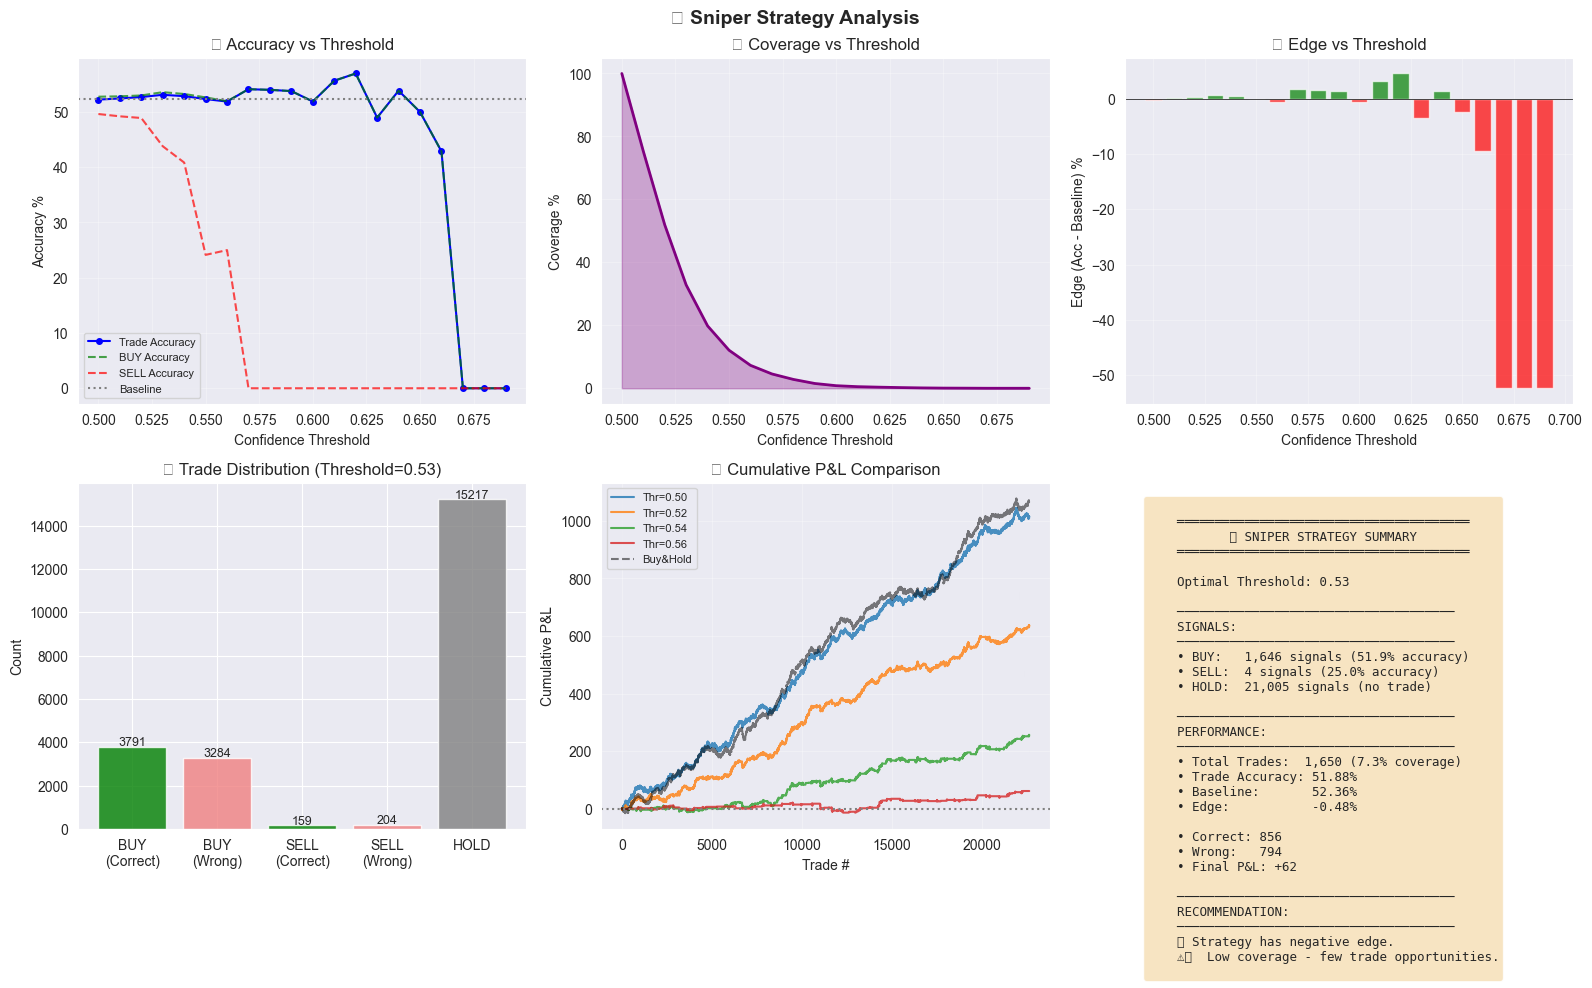

💾 Saved: cnn_patch_models_v3/sniper_analysis.png


FileNotFoundError: [Errno 2] No such file or directory: 'cnn_patch_models/pnl_detailed.png'

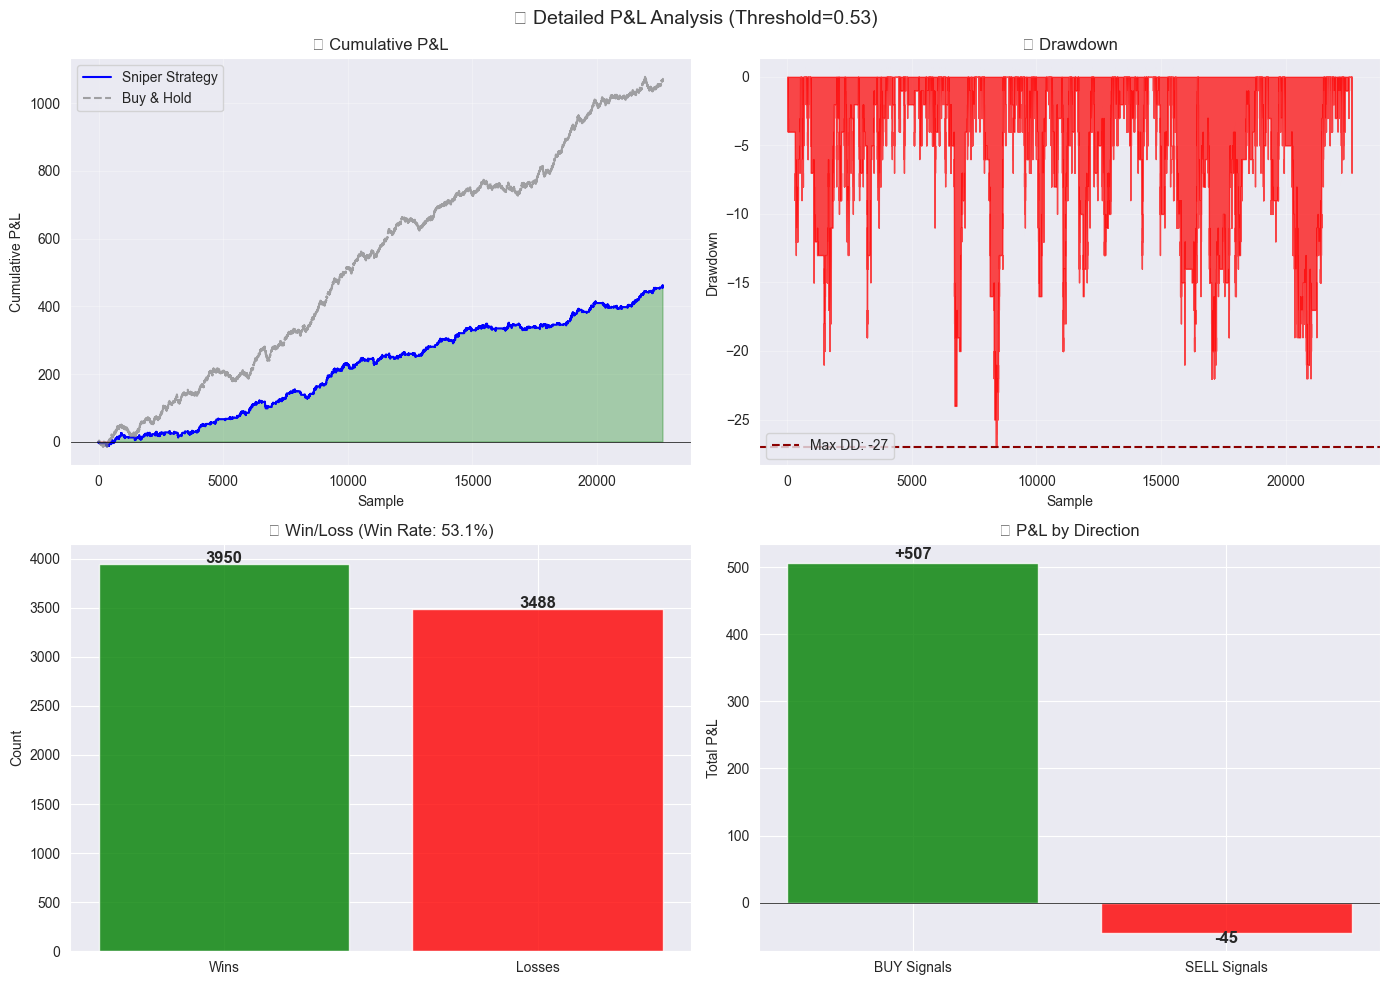

In [32]:
"""
🎯 SNIPER STRATEGY BACKTEST
===========================
Тестируем стратегию с тремя опциями:
- BUY (уверены что UP)
- SELL (уверены что DOWN)
- HOLD (не уверены — ничего не делаем)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datetime import datetime

# ══════════════════════════════════════════════════════════════
#                    SNIPER STRATEGY
# ══════════════════════════════════════════════════════════════

class SniperStrategy:
    """
    Снайперская стратегия:
    - Торгуем только когда модель уверена
    - Можем сказать "HOLD" (ничего не делать)
    """

    def __init__(self, predictions, targets, confidences,
                 conf_threshold=0.55,
                 up_threshold=None,    # Отдельный порог для UP
                 down_threshold=None): # Отдельный порог для DOWN

        self.P = predictions
        self.T = targets
        self.C = confidences
        self.n_samples = len(predictions)

        # Пороги
        self.conf_threshold = conf_threshold
        self.up_threshold = up_threshold or conf_threshold
        self.down_threshold = down_threshold or conf_threshold

    def get_signals(self):
        """
        Генерирует торговые сигналы:
        - 1: BUY (предсказываем UP с высокой уверенностью)
        - -1: SELL (предсказываем DOWN с высокой уверенностью)
        - 0: HOLD (не уверены — ничего не делаем)
        """
        signals = np.zeros(self.n_samples, dtype=int)

        for i in range(self.n_samples):
            if self.P[i] == 1 and self.C[i] > self.up_threshold:
                signals[i] = 1  # BUY
            elif self.P[i] == 0 and self.C[i] > self.down_threshold:
                signals[i] = -1  # SELL
            else:
                signals[i] = 0  # HOLD

        return signals

    def evaluate(self):
        """Оценка стратегии"""
        signals = self.get_signals()

        # Статистика сигналов
        n_buy = (signals == 1).sum()
        n_sell = (signals == -1).sum()
        n_hold = (signals == 0).sum()
        n_trades = n_buy + n_sell

        # Accuracy по типам сигналов
        buy_mask = signals == 1
        sell_mask = signals == -1
        trade_mask = signals != 0

        # Правильность
        buy_correct = (self.T[buy_mask] == 1).sum() if n_buy > 0 else 0
        sell_correct = (self.T[sell_mask] == 0).sum() if n_sell > 0 else 0
        total_correct = buy_correct + sell_correct

        # Accuracy
        buy_acc = buy_correct / n_buy * 100 if n_buy > 0 else 0
        sell_acc = sell_correct / n_sell * 100 if n_sell > 0 else 0
        trade_acc = total_correct / n_trades * 100 if n_trades > 0 else 0

        # Baseline: всегда UP
        baseline_acc = self.T.mean() * 100

        # P&L симуляция (простая: +1 за правильную сделку, -1 за неправильную)
        pnl = np.zeros(self.n_samples)
        for i in range(self.n_samples):
            if signals[i] == 1:  # BUY
                pnl[i] = 1 if self.T[i] == 1 else -1
            elif signals[i] == -1:  # SELL
                pnl[i] = 1 if self.T[i] == 0 else -1
            # HOLD: pnl = 0

        cum_pnl = np.cumsum(pnl)

        return {
            'n_samples': self.n_samples,
            'n_buy': n_buy,
            'n_sell': n_sell,
            'n_hold': n_hold,
            'n_trades': n_trades,
            'coverage': n_trades / self.n_samples * 100,

            'buy_acc': buy_acc,
            'sell_acc': sell_acc,
            'trade_acc': trade_acc,
            'baseline_acc': baseline_acc,
            'edge': trade_acc - baseline_acc,

            'total_correct': total_correct,
            'total_wrong': n_trades - total_correct,

            'final_pnl': cum_pnl[-1] if len(cum_pnl) > 0 else 0,
            'cum_pnl': cum_pnl,
            'signals': signals,
            'pnl': pnl
        }


def run_threshold_analysis(P, T, C):
    """Анализ по разным порогам confidence"""

    results = []

    # Пробуем разные пороги
    thresholds = np.arange(0.50, 0.70, 0.01)

    for thr in thresholds:
        strategy = SniperStrategy(P, T, C, conf_threshold=thr)
        r = strategy.evaluate()
        r['threshold'] = thr
        results.append(r)

    return pd.DataFrame(results)


def run_asymmetric_analysis(P, T, C):
    """
    Анализ с разными порогами для UP и DOWN.
    Может быть полезно если модель лучше предсказывает одно направление.
    """

    results = []

    for up_thr in np.arange(0.50, 0.65, 0.02):
        for down_thr in np.arange(0.50, 0.65, 0.02):
            strategy = SniperStrategy(P, T, C,
                                     up_threshold=up_thr,
                                     down_threshold=down_thr)
            r = strategy.evaluate()
            r['up_threshold'] = up_thr
            r['down_threshold'] = down_thr
            results.append(r)

    return pd.DataFrame(results)


# ══════════════════════════════════════════════════════════════
#                    VISUALIZATION
# ══════════════════════════════════════════════════════════════

def plot_sniper_analysis(P, T, C, save_path='sniper_analysis.png'):
    """Полный анализ снайперской стратегии"""

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('🎯 Sniper Strategy Analysis', fontsize=14, fontweight='bold')

    # 1. Threshold Analysis
    ax = axes[0, 0]
    df = run_threshold_analysis(P, T, C)

    ax.plot(df['threshold'], df['trade_acc'], 'b-o', label='Trade Accuracy', markersize=4)
    ax.plot(df['threshold'], df['buy_acc'], 'g--', label='BUY Accuracy', alpha=0.7)
    ax.plot(df['threshold'], df['sell_acc'], 'r--', label='SELL Accuracy', alpha=0.7)
    ax.axhline(y=df['baseline_acc'].iloc[0], color='gray', linestyle=':', label='Baseline')
    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Accuracy %')
    ax.set_title('📊 Accuracy vs Threshold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # 2. Coverage vs Threshold
    ax = axes[0, 1]
    ax.plot(df['threshold'], df['coverage'], 'purple', linewidth=2)
    ax.fill_between(df['threshold'], 0, df['coverage'], alpha=0.3, color='purple')
    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Coverage %')
    ax.set_title('📊 Coverage vs Threshold')
    ax.grid(True, alpha=0.3)

    # 3. Edge vs Threshold
    ax = axes[0, 2]
    colors = ['green' if e > 0 else 'red' for e in df['edge']]
    ax.bar(df['threshold'], df['edge'], color=colors, alpha=0.7, width=0.008)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Confidence Threshold')
    ax.set_ylabel('Edge (Acc - Baseline) %')
    ax.set_title('📈 Edge vs Threshold')
    ax.grid(True, alpha=0.3)

    # 4. Trade Distribution at optimal threshold
    ax = axes[1, 0]

    # Находим оптимальный порог (максимальный edge при coverage > 5%)
    valid = df[df['coverage'] > 5]
    if len(valid) > 0:
        best_idx = valid['edge'].idxmax()
        best_thr = df.loc[best_idx, 'threshold']
    else:
        best_thr = 0.52

    strategy = SniperStrategy(P, T, C, conf_threshold=best_thr)
    r = strategy.evaluate()

    labels = ['BUY\n(Correct)', 'BUY\n(Wrong)', 'SELL\n(Correct)', 'SELL\n(Wrong)', 'HOLD']

    buy_correct = ((r['signals'] == 1) & (T == 1)).sum()
    buy_wrong = ((r['signals'] == 1) & (T == 0)).sum()
    sell_correct = ((r['signals'] == -1) & (T == 0)).sum()
    sell_wrong = ((r['signals'] == -1) & (T == 1)).sum()
    hold = r['n_hold']

    values = [buy_correct, buy_wrong, sell_correct, sell_wrong, hold]
    colors = ['green', 'lightcoral', 'green', 'lightcoral', 'gray']

    ax.bar(labels, values, color=colors, alpha=0.8)
    ax.set_ylabel('Count')
    ax.set_title(f'📊 Trade Distribution (Threshold={best_thr:.2f})')
    for i, v in enumerate(values):
        ax.text(i, v + 50, str(v), ha='center', fontsize=9)

    # 5. Cumulative P&L
    ax = axes[1, 1]

    # Сравниваем несколько стратегий
    for thr in [0.50, 0.52, 0.54, 0.56]:
        strategy = SniperStrategy(P, T, C, conf_threshold=thr)
        r = strategy.evaluate()
        ax.plot(r['cum_pnl'], label=f'Thr={thr:.2f}', alpha=0.8)

    # Buy & Hold baseline
    buy_hold_pnl = np.cumsum(np.where(T == 1, 1, -1))
    ax.plot(buy_hold_pnl, 'k--', label='Buy&Hold', alpha=0.5)

    ax.axhline(y=0, color='gray', linestyle=':')
    ax.set_xlabel('Trade #')
    ax.set_ylabel('Cumulative P&L')
    ax.set_title('📈 Cumulative P&L Comparison')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # 6. Summary Table
    ax = axes[1, 2]
    ax.axis('off')

    # Лучшая стратегия
    best_r = strategy.evaluate()

    summary_text = f"""
    ═══════════════════════════════════════
           🎯 SNIPER STRATEGY SUMMARY
    ═══════════════════════════════════════

    Optimal Threshold: {best_thr:.2f}

    ─────────────────────────────────────
    SIGNALS:
    ─────────────────────────────────────
    • BUY:   {r['n_buy']:,} signals ({r['buy_acc']:.1f}% accuracy)
    • SELL:  {r['n_sell']:,} signals ({r['sell_acc']:.1f}% accuracy)
    • HOLD:  {r['n_hold']:,} signals (no trade)

    ─────────────────────────────────────
    PERFORMANCE:
    ─────────────────────────────────────
    • Total Trades:  {r['n_trades']:,} ({r['coverage']:.1f}% coverage)
    • Trade Accuracy: {r['trade_acc']:.2f}%
    • Baseline:       {r['baseline_acc']:.2f}%
    • Edge:           {r['edge']:+.2f}%

    • Correct: {r['total_correct']:,}
    • Wrong:   {r['total_wrong']:,}
    • Final P&L: {r['final_pnl']:+.0f}

    ─────────────────────────────────────
    RECOMMENDATION:
    ─────────────────────────────────────
    {'✅ Strategy has positive edge!' if r['edge'] > 0 else '❌ Strategy has negative edge.'}
    {'⚠️  Low coverage - few trade opportunities.' if r['coverage'] < 20 else ''}
    """

    ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"💾 Saved: {save_path}")

    return df, best_thr


def plot_detailed_pnl(P, T, C, threshold=0.52, save_path='pnl_detailed.png'):
    """Детальный анализ P&L"""

    strategy = SniperStrategy(P, T, C, conf_threshold=threshold)
    r = strategy.evaluate()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'💰 Detailed P&L Analysis (Threshold={threshold})', fontsize=14)

    # 1. Cumulative P&L with drawdown
    ax = axes[0, 0]
    cum_pnl = r['cum_pnl']

    ax.plot(cum_pnl, 'b-', linewidth=1.5, label='Sniper Strategy')
    ax.fill_between(range(len(cum_pnl)), 0, cum_pnl,
                    where=cum_pnl >= 0, alpha=0.3, color='green')
    ax.fill_between(range(len(cum_pnl)), 0, cum_pnl,
                    where=cum_pnl < 0, alpha=0.3, color='red')

    # Buy & Hold
    buy_hold = np.cumsum(np.where(T == 1, 1, -1))
    ax.plot(buy_hold, 'gray', linestyle='--', alpha=0.7, label='Buy & Hold')

    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Cumulative P&L')
    ax.set_title('📈 Cumulative P&L')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Drawdown
    ax = axes[0, 1]
    running_max = np.maximum.accumulate(cum_pnl)
    drawdown = cum_pnl - running_max

    ax.fill_between(range(len(drawdown)), drawdown, 0, alpha=0.7, color='red')
    ax.set_xlabel('Sample')
    ax.set_ylabel('Drawdown')
    ax.set_title('📉 Drawdown')
    ax.grid(True, alpha=0.3)

    max_dd = drawdown.min()
    ax.axhline(y=max_dd, color='darkred', linestyle='--', label=f'Max DD: {max_dd:.0f}')
    ax.legend()

    # 3. Win/Loss Distribution
    ax = axes[1, 0]

    trade_mask = r['signals'] != 0
    trade_results = r['pnl'][trade_mask]

    wins = (trade_results == 1).sum()
    losses = (trade_results == -1).sum()

    ax.bar(['Wins', 'Losses'], [wins, losses], color=['green', 'red'], alpha=0.8)
    ax.set_ylabel('Count')
    ax.set_title(f'🎲 Win/Loss (Win Rate: {wins/(wins+losses)*100:.1f}%)')

    for i, v in enumerate([wins, losses]):
        ax.text(i, v + 10, str(v), ha='center', fontsize=12, fontweight='bold')

    # 4. P&L by direction
    ax = axes[1, 1]

    buy_signals = r['signals'] == 1
    sell_signals = r['signals'] == -1

    buy_pnl = r['pnl'][buy_signals].sum() if buy_signals.sum() > 0 else 0
    sell_pnl = r['pnl'][sell_signals].sum() if sell_signals.sum() > 0 else 0

    colors = ['green' if buy_pnl >= 0 else 'red',
              'green' if sell_pnl >= 0 else 'red']

    ax.bar(['BUY Signals', 'SELL Signals'], [buy_pnl, sell_pnl], color=colors, alpha=0.8)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_ylabel('Total P&L')
    ax.set_title('📊 P&L by Direction')

    for i, v in enumerate([buy_pnl, sell_pnl]):
        ax.text(i, v + (5 if v >= 0 else -15), f'{v:+.0f}', ha='center', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"💾 Saved: {save_path}")


def print_strategy_comparison(P, T, C):
    """Сравнение разных стратегий"""

    print("\n" + "═" * 80)
    print("📊 STRATEGY COMPARISON")
    print("═" * 80)

    baseline = T.mean() * 100
    print(f"\nBaseline (always UP): {baseline:.2f}%")
    print(f"Total samples: {len(T):,}")

    print("\n" + "─" * 80)
    print(f"{'Threshold':<12} {'Coverage':<12} {'Trades':<10} {'Accuracy':<12} {'Edge':<10} {'P&L':<10}")
    print("─" * 80)

    for thr in [0.50, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.58, 0.60]:
        strategy = SniperStrategy(P, T, C, conf_threshold=thr)
        r = strategy.evaluate()

        edge_str = f"{r['edge']:+.2f}%" if r['n_trades'] > 0 else "N/A"
        acc_str = f"{r['trade_acc']:.2f}%" if r['n_trades'] > 0 else "N/A"

        marker = "✅" if r['edge'] > 0 and r['n_trades'] > 100 else "  "

        print(f"{marker} {thr:<10.2f} {r['coverage']:<10.1f}% {r['n_trades']:<10,} {acc_str:<12} {edge_str:<10} {r['final_pnl']:+.0f}")

    print("─" * 80)
    print("\n✅ = Positive edge with >100 trades")


# ══════════════════════════════════════════════════════════════
#                    MAIN EXECUTION
# ══════════════════════════════════════════════════════════════

if __name__ == "__main__":
    # Загружаем результаты из evaluate()
    # Предполагаем что переменная m уже существует после evaluate()

    # Если m не существует, загрузи модель и сделай evaluate:
    """
    model, checkpoint = load_checkpoint(model, 'cnn_patch_models/model_final_calibrated.pt', cfg.DEVICE)
    m = evaluate(model, test_loader, cfg.DEVICE)
    """

    # Используем данные из m
    P = m['P']  # Predictions
    T = m['T']  # Targets
    C = m['C']  # Confidences

    print("🎯 SNIPER STRATEGY BACKTEST")
    print("=" * 50)
    print(f"Total samples: {len(P):,}")
    print(f"Confidence range: [{C.min():.3f}, {C.max():.3f}]")
    print(f"Confidence mean: {C.mean():.3f} ± {C.std():.3f}")

    # 1. Сравнение стратегий
    print_strategy_comparison(P, T, C)

    # 2. Визуальный анализ
    df, best_thr = plot_sniper_analysis(P, T, C, 'cnn_patch_models_v3/sniper_analysis.png')

    # 3. Детальный P&L
    plot_detailed_pnl(P, T, C, threshold=best_thr, save_path='cnn_patch_models/pnl_detailed.png')

    print("\n✅ Analysis complete!")

📊 Loading test data with ticker info...
   Loaded 42 tickers

════════════════════════════════════════════════════════════════════════════════════════════════════
📊 PER-TICKER ANALYSIS
════════════════════════════════════════════════════════════════════════════════════════════════════

Ticker   Samples    Accuracy     UP%        Conf       HiConf Trades   HiConf Acc   Edge       P&L     
────────────────────────────────────────────────────────────────────────────────────────────────────
🌟ABBV    351        58.40      % 57.5     % 0.530       240 (68.4%)    58.3%        +0.8%      +40
🌟CVX     545        55.60      % 54.1     % 0.523       256 (47.0%)    53.9%        -0.2%      +20
🌟HD      542        55.17      % 54.4     % 0.530       269 (49.6%)    52.4%        -2.0%      +13
✅TMO     545        54.68      % 54.7     % 0.527       357 (65.5%)    54.1%        -0.6%      +29
✅DHR     545        54.68      % 52.7     % 0.528       338 (62.0%)    52.4%        -0.3%      +16
✅COP     545 

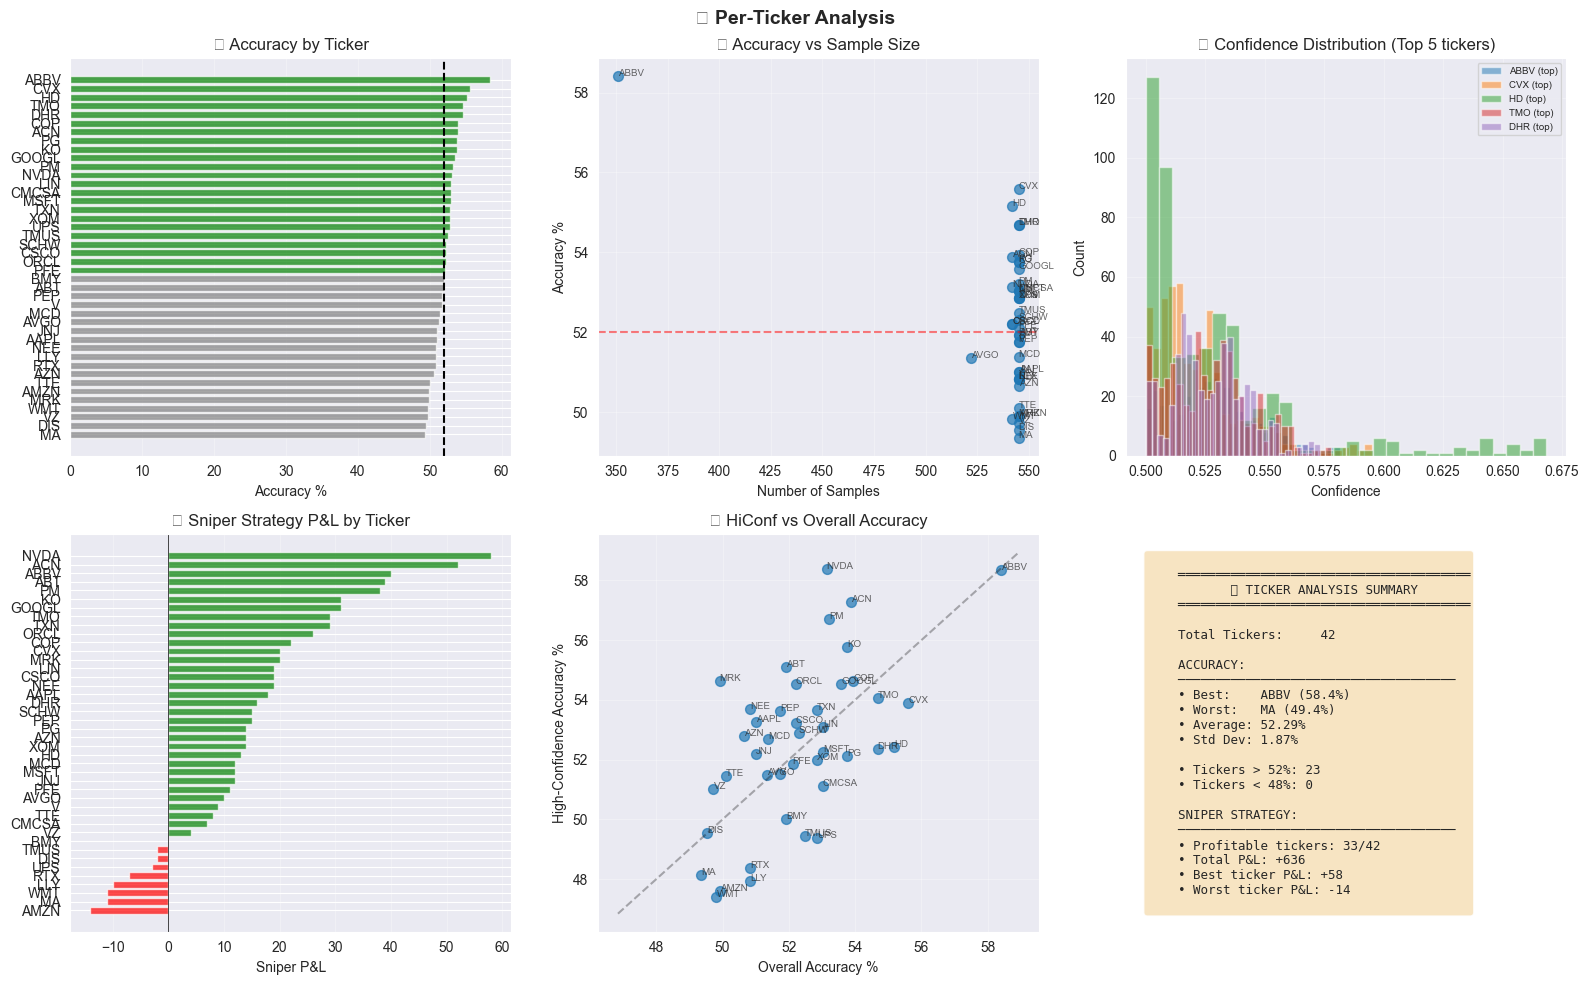

💾 Saved: cnn_patch_models_v3/ticker_analysis.png

📈 Detailed analysis for top 3 tickers:
💾 Saved: cnn_patch_models_v3/ticker_ABBV_detail.png


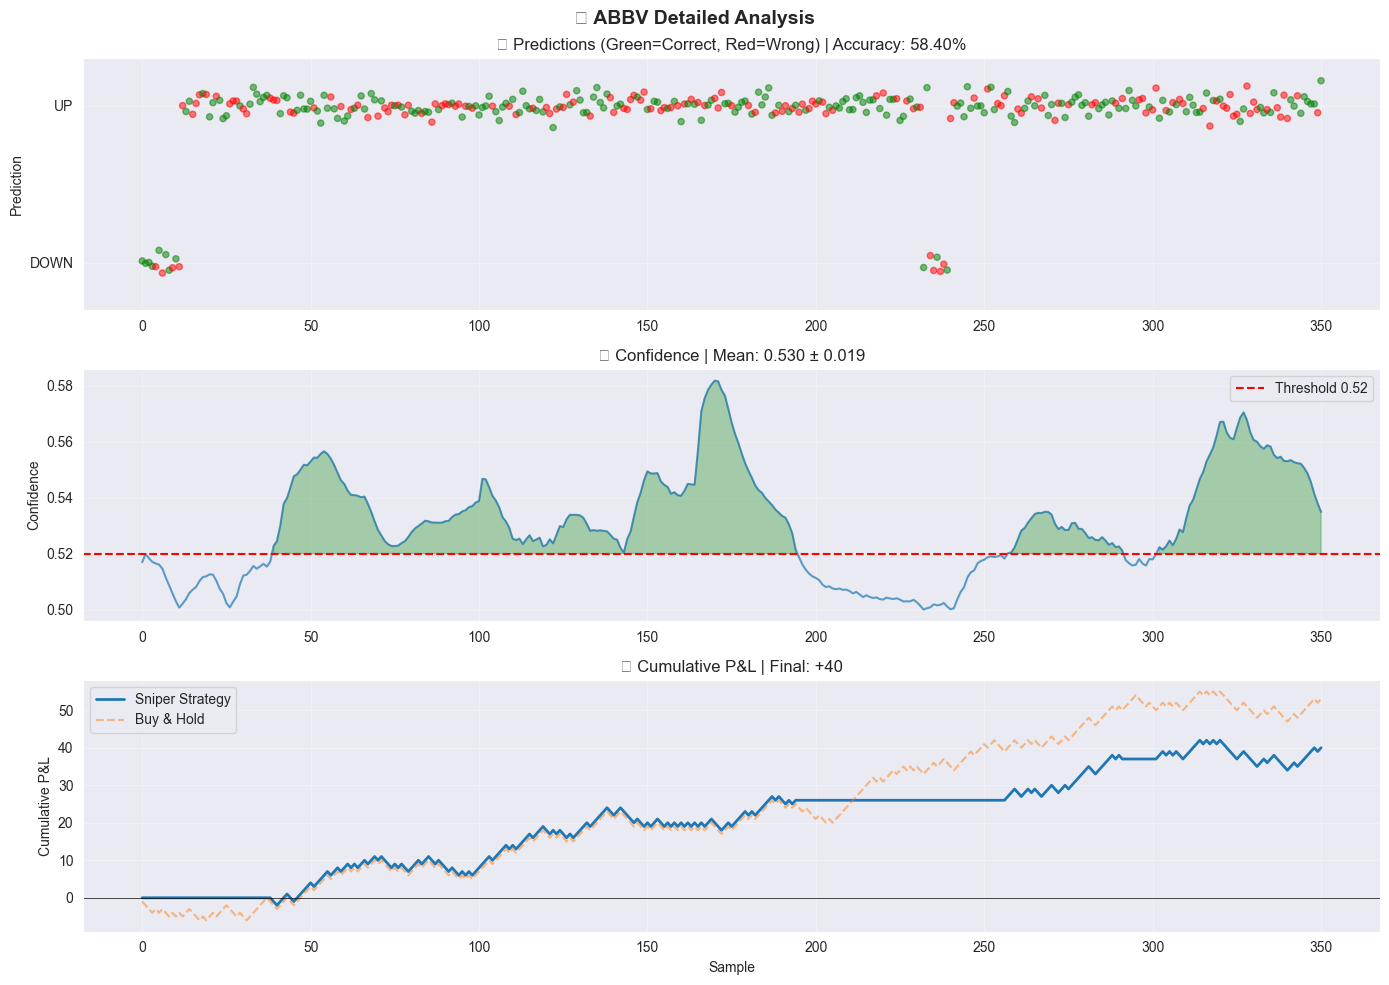

💾 Saved: cnn_patch_models_v3/ticker_CVX_detail.png


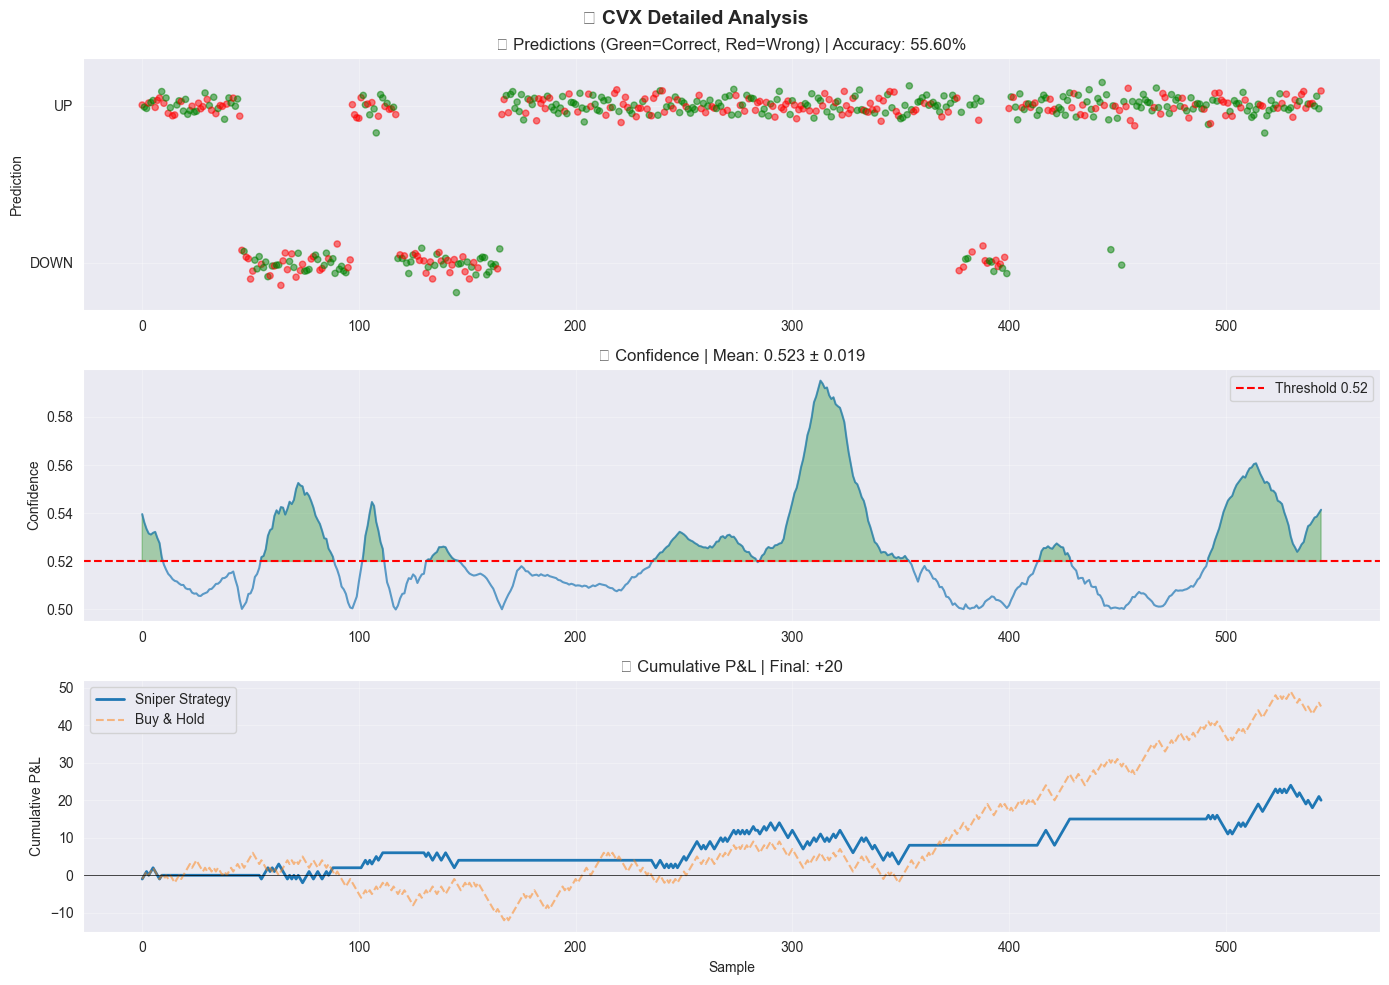

💾 Saved: cnn_patch_models_v3/ticker_HD_detail.png


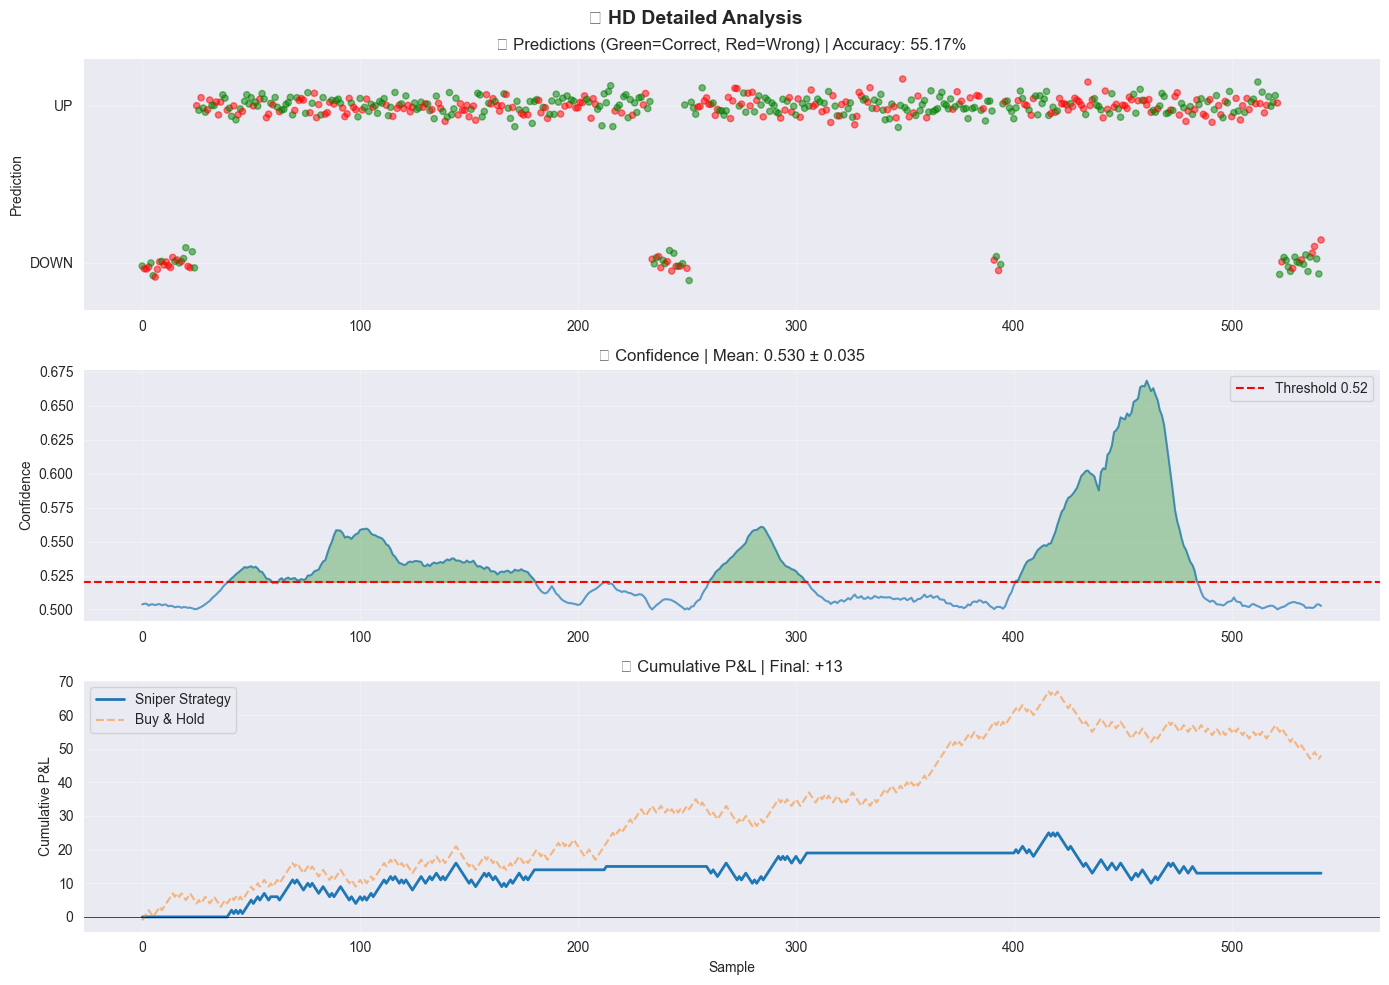


📉 Detailed analysis for bottom 3 tickers:
💾 Saved: cnn_patch_models_v3/ticker_MA_detail.png


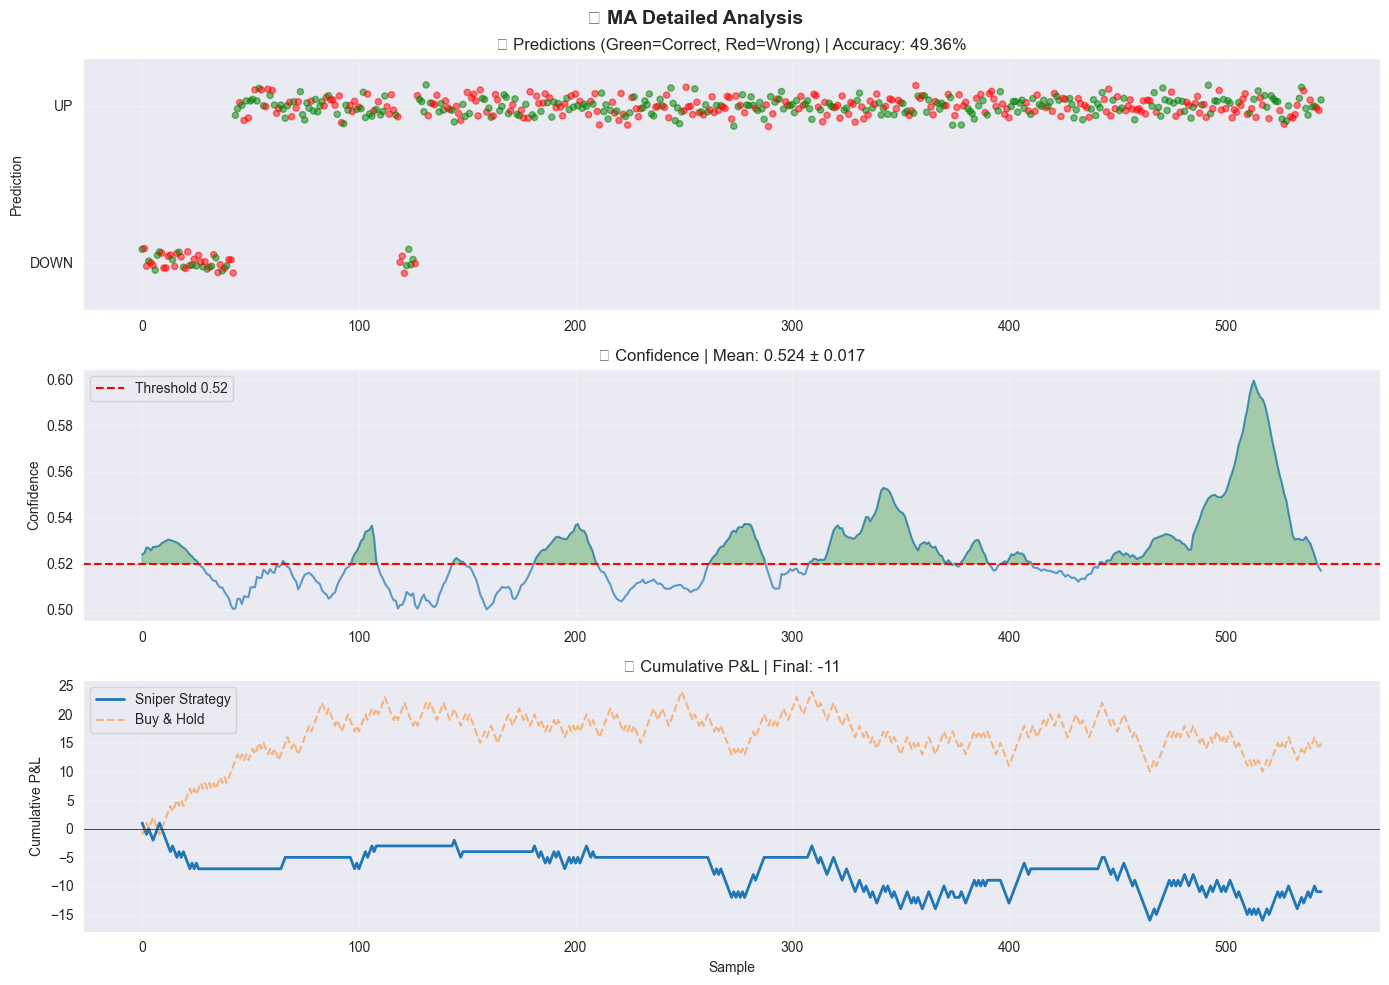

💾 Saved: cnn_patch_models_v3/ticker_DIS_detail.png


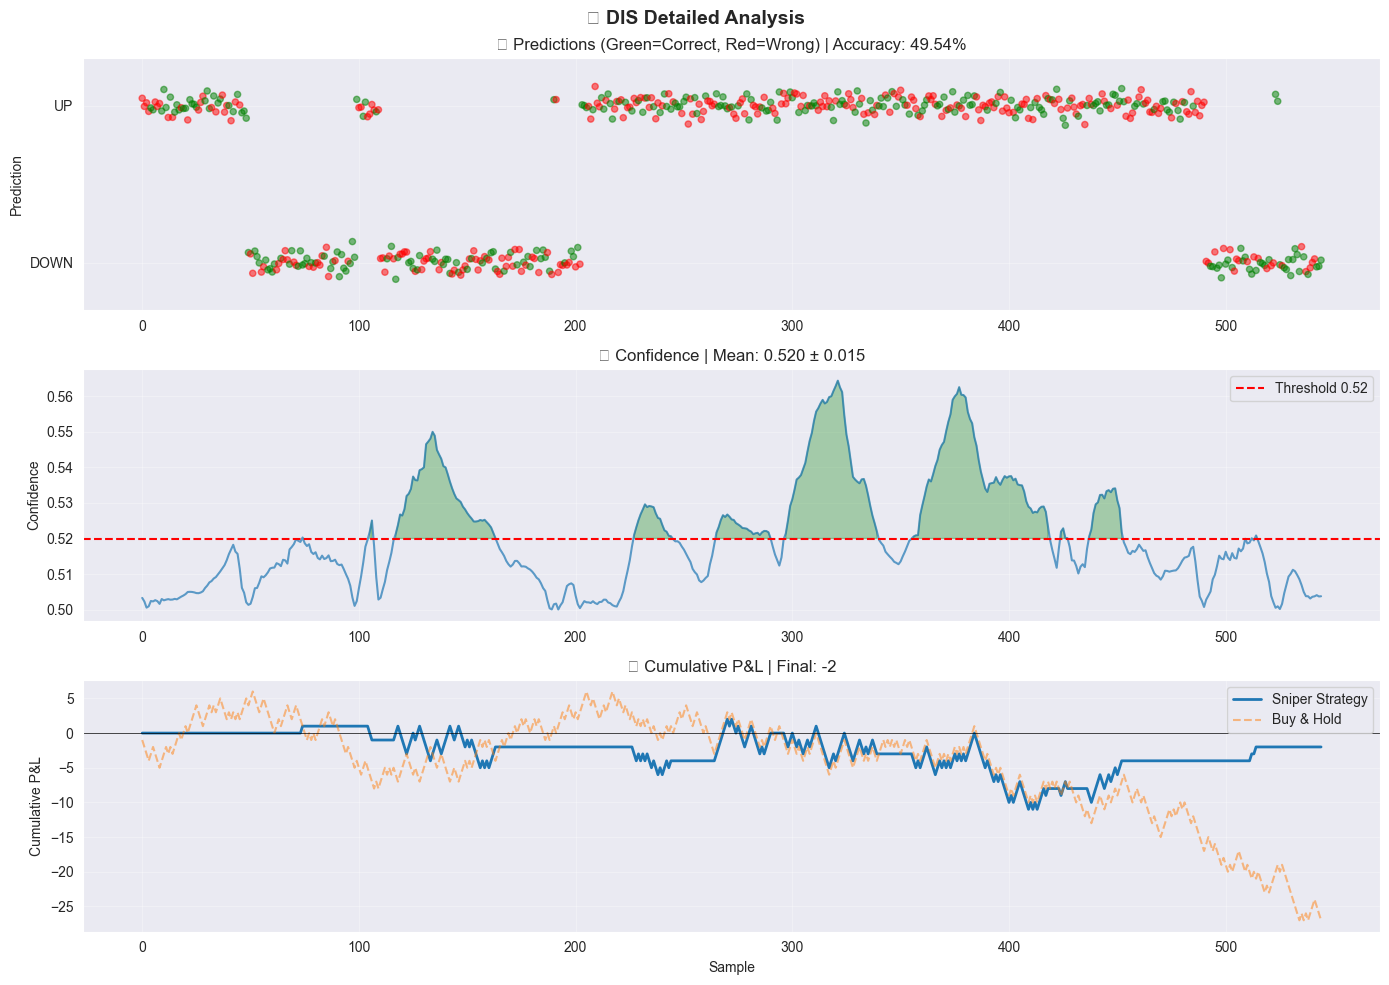

💾 Saved: cnn_patch_models_v3/ticker_VZ_detail.png


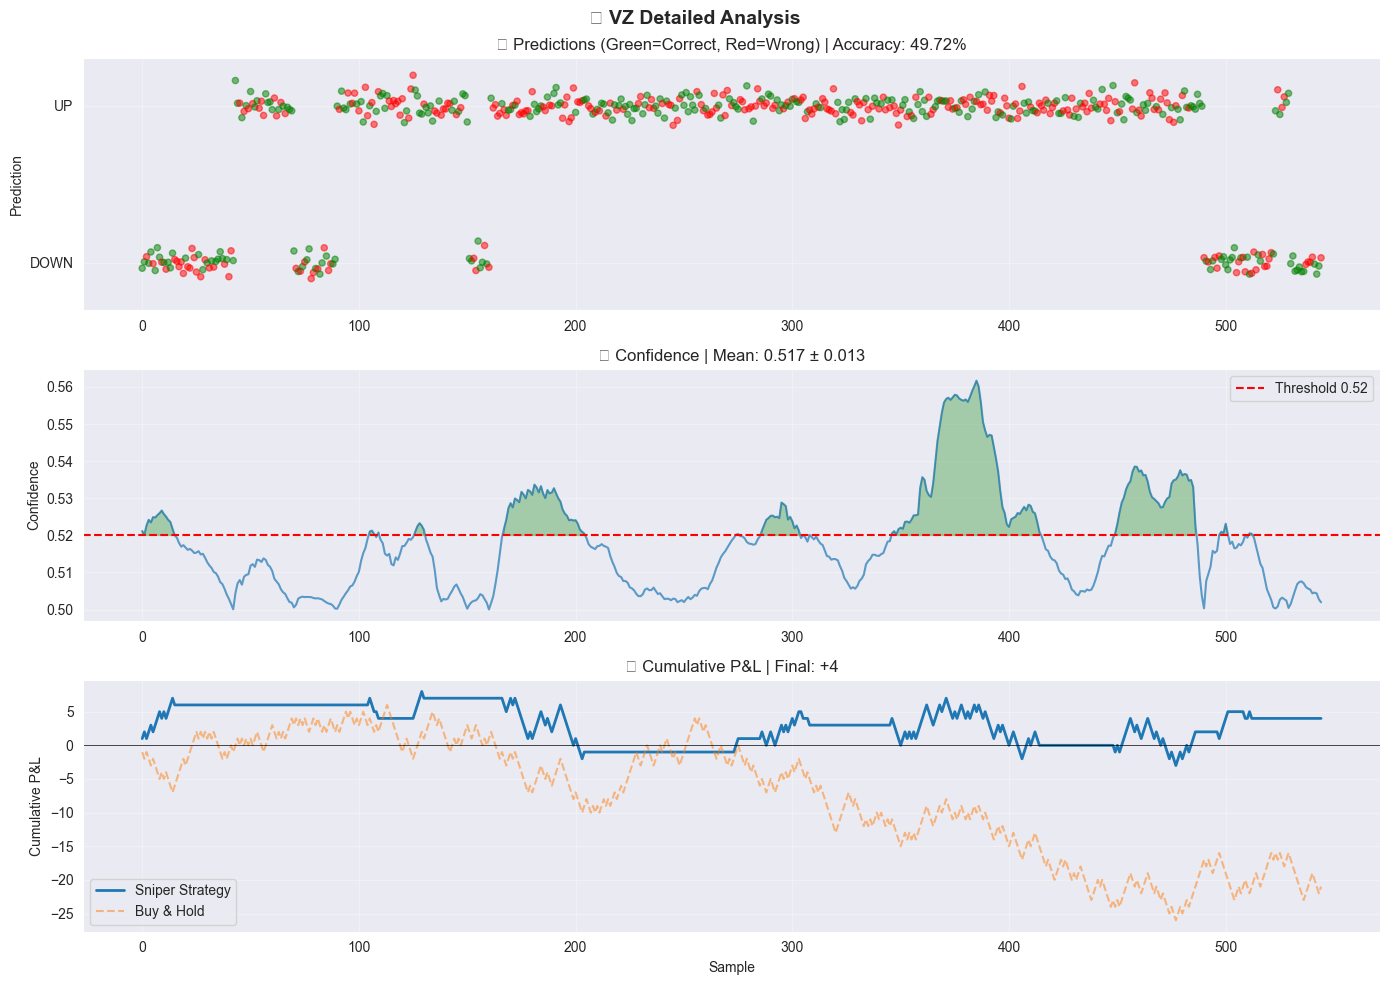

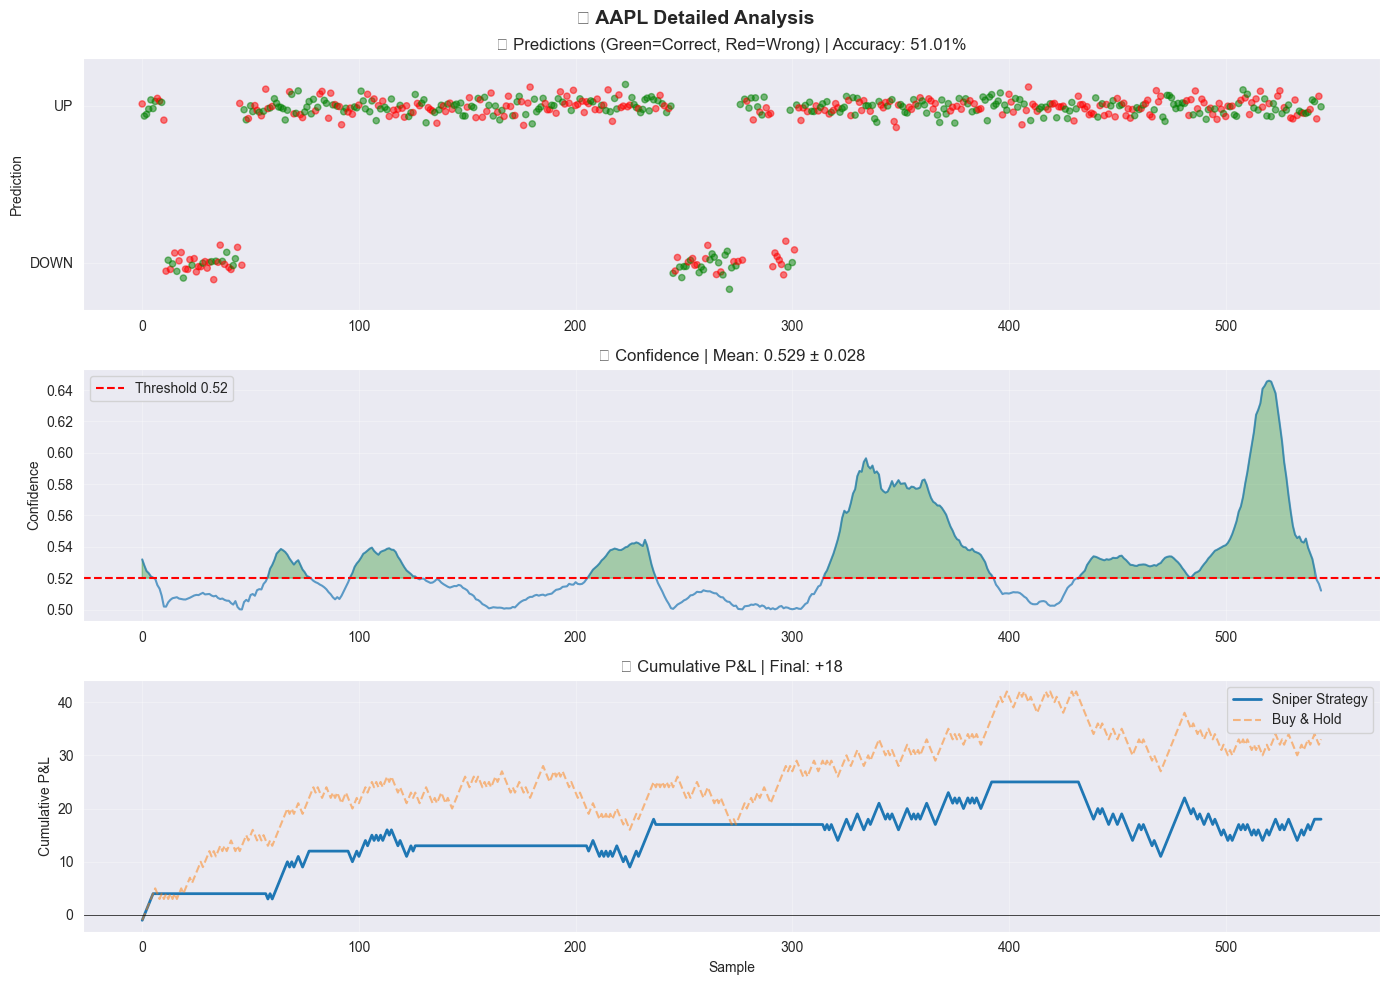

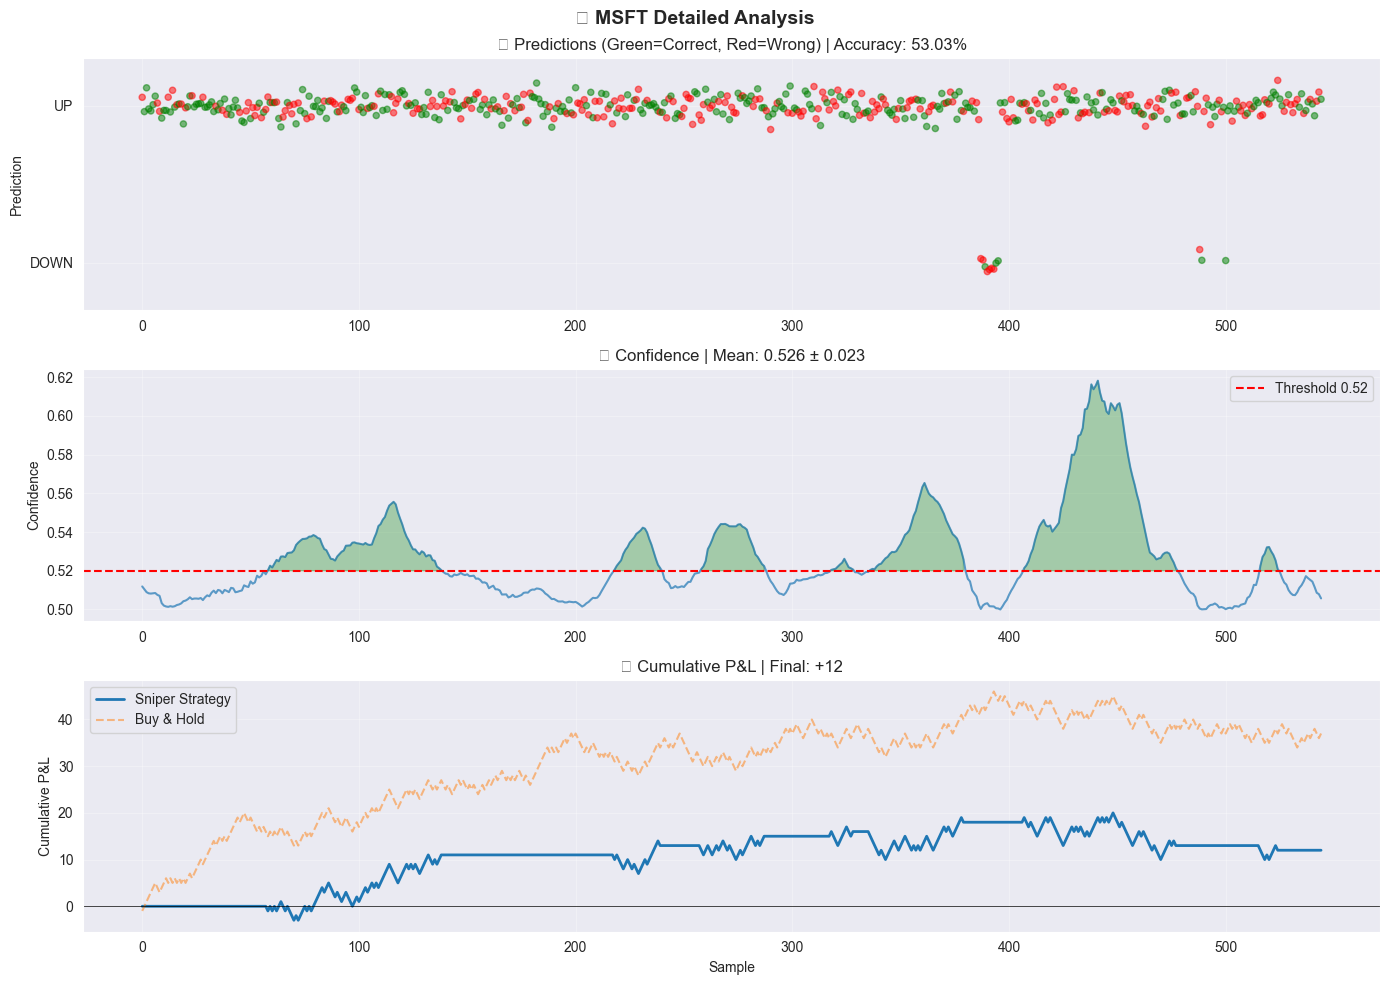

In [31]:
"""
📊 PER-TICKER ANALYSIS
======================
Анализ работы модели на каждом тикере отдельно
"""

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import defaultdict

# ══════════════════════════════════════════════════════════════
#              LOAD DATA WITH TICKER INFO
# ══════════════════════════════════════════════════════════════

def load_test_data_with_tickers(folder, seq_len, norm_window, model, device):
    """
    Загружает тестовые данные И сохраняет информацию о тикерах.
    Возвращает predictions, targets, confidences для каждого тикера.
    """

    ticker_results = {}
    files = [f for f in os.listdir(folder) if f.endswith('.csv')]

    model.eval()

    for file in files:
        try:
            ticker = file.split('_')[0]  # AAPL_fundamentals_test.csv → AAPL

            df = pd.read_csv(os.path.join(folder, file))
            df.columns = df.columns.str.lower().str.strip()

            if 'close' not in df.columns:
                continue
            if 'date' in df.columns:
                df = df.sort_values('date').reset_index(drop=True)
                dates = df['date'].values
            else:
                dates = np.arange(len(df))

            df = create_features(df)
            df['target'] = (df['close'].shift(-1) > df['close']).astype(int)

            # Сохраняем цены для анализа
            prices = df['close'].values.copy()

            df = df.replace([np.inf, -np.inf], np.nan).dropna()

            if len(df) < seq_len + norm_window:
                continue

            exclude = ['date', 'close', 'target', 'open', 'high', 'low']
            cols = [c for c in df.columns if c not in exclude
                   and df[c].dtype in ['float64', 'int64', 'float32']]

            raw = df[cols].values
            features = rolling_normalize(raw, norm_window)
            targets = df['target'].values

            # Собираем samples
            samples_X, samples_y, sample_dates, sample_prices = [], [], [], []

            for i in range(norm_window, len(features) - seq_len):
                samples_X.append(features[i:i + seq_len])
                samples_y.append(targets[i + seq_len - 1])
                sample_dates.append(dates[i + seq_len - 1] if i + seq_len - 1 < len(dates) else i)
                sample_prices.append(prices[i + seq_len - 1] if i + seq_len - 1 < len(prices) else 0)

            if len(samples_X) < 10:
                continue

            # Predict
            X = torch.FloatTensor(np.array(samples_X)).to(device)

            with torch.no_grad():
                logits, conf = model(X)
                preds = logits.argmax(dim=-1).cpu().numpy()
                confs = conf.cpu().numpy()

            targets_arr = np.array(samples_y)

            ticker_results[ticker] = {
                'predictions': preds,
                'targets': targets_arr,
                'confidences': confs,
                'dates': sample_dates,
                'prices': np.array(sample_prices),
                'n_samples': len(preds),
                'accuracy': (preds == targets_arr).mean() * 100,
                'up_ratio': targets_arr.mean() * 100,
                'pred_up_ratio': preds.mean() * 100,
                'conf_mean': confs.mean(),
                'conf_std': confs.std()
            }

        except Exception as e:
            print(f"Error processing {file}: {e}")
            continue

    return ticker_results


def analyze_per_ticker(ticker_results, conf_threshold=0.52):
    """Анализ результатов по каждому тикеру"""

    print("\n" + "═" * 100)
    print("📊 PER-TICKER ANALYSIS")
    print("═" * 100)

    # Собираем статистику
    stats = []

    for ticker, data in ticker_results.items():
        P, T, C = data['predictions'], data['targets'], data['confidences']

        # High confidence trades
        hc_mask = C > conf_threshold
        hc_trades = hc_mask.sum()

        if hc_trades > 10:
            hc_acc = (P[hc_mask] == T[hc_mask]).mean() * 100
        else:
            hc_acc = 0

        # Sniper P&L
        pnl = 0
        for i in range(len(P)):
            if C[i] > conf_threshold:
                if P[i] == 1:  # BUY
                    pnl += 1 if T[i] == 1 else -1
                else:  # SELL
                    pnl += 1 if T[i] == 0 else -1

        stats.append({
            'ticker': ticker,
            'samples': data['n_samples'],
            'accuracy': data['accuracy'],
            'up_ratio': data['up_ratio'],
            'conf_mean': data['conf_mean'],
            'hc_trades': hc_trades,
            'hc_coverage': hc_trades / len(P) * 100 if len(P) > 0 else 0,
            'hc_accuracy': hc_acc,
            'sniper_pnl': pnl,
            'edge': hc_acc - data['up_ratio'] if hc_acc > 0 else 0
        })

    df = pd.DataFrame(stats)
    df = df.sort_values('accuracy', ascending=False)

    # Print table
    print(f"\n{'Ticker':<8} {'Samples':<10} {'Accuracy':<12} {'UP%':<10} {'Conf':<10} {'HiConf Trades':<15} {'HiConf Acc':<12} {'Edge':<10} {'P&L':<8}")
    print("─" * 100)

    for _, row in df.iterrows():
        edge_str = f"{row['edge']:+.1f}%" if row['hc_accuracy'] > 0 else "N/A"
        hc_str = f"{row['hc_trades']:>4} ({row['hc_coverage']:.1f}%)"
        hc_acc_str = f"{row['hc_accuracy']:.1f}%" if row['hc_accuracy'] > 0 else "N/A"

        # Markers
        marker = ""
        if row['accuracy'] > 55:
            marker = "🌟"
        elif row['accuracy'] > 52:
            marker = "✅"
        elif row['accuracy'] < 48:
            marker = "❌"

        print(f"{marker}{row['ticker']:<7} {row['samples']:<10} {row['accuracy']:<11.2f}% {row['up_ratio']:<9.1f}% "
              f"{row['conf_mean']:<10.3f} {hc_str:<15} {hc_acc_str:<12} {edge_str:<10} {row['sniper_pnl']:+.0f}")

    print("─" * 100)

    # Summary
    print(f"\n📈 SUMMARY:")
    print(f"   Total tickers: {len(df)}")
    print(f"   Best ticker: {df.iloc[0]['ticker']} ({df.iloc[0]['accuracy']:.2f}%)")
    print(f"   Worst ticker: {df.iloc[-1]['ticker']} ({df.iloc[-1]['accuracy']:.2f}%)")
    print(f"   Average accuracy: {df['accuracy'].mean():.2f}%")
    print(f"   Tickers > 52%: {(df['accuracy'] > 52).sum()}")
    print(f"   Tickers < 48%: {(df['accuracy'] < 48).sum()}")

    return df


def plot_ticker_analysis(ticker_results, df_stats, save_path='ticker_analysis.png'):
    """Визуализация по тикерам"""

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('📊 Per-Ticker Analysis', fontsize=14, fontweight='bold')

    # 1. Accuracy by ticker (bar chart)
    ax = axes[0, 0]
    df_sorted = df_stats.sort_values('accuracy', ascending=True)
    colors = ['green' if a > 52 else 'red' if a < 48 else 'gray' for a in df_sorted['accuracy']]
    ax.barh(df_sorted['ticker'], df_sorted['accuracy'], color=colors, alpha=0.7)
    ax.axvline(x=52, color='black', linestyle='--', label='Baseline ~52%')
    ax.set_xlabel('Accuracy %')
    ax.set_title('🎯 Accuracy by Ticker')
    ax.grid(True, alpha=0.3, axis='x')

    # 2. Accuracy vs Samples
    ax = axes[0, 1]
    ax.scatter(df_stats['samples'], df_stats['accuracy'], alpha=0.7, s=50)
    for _, row in df_stats.iterrows():
        ax.annotate(row['ticker'], (row['samples'], row['accuracy']), fontsize=7, alpha=0.7)
    ax.axhline(y=52, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Number of Samples')
    ax.set_ylabel('Accuracy %')
    ax.set_title('📊 Accuracy vs Sample Size')
    ax.grid(True, alpha=0.3)

    # 3. Confidence distribution by ticker (top 5 and bottom 5)
    ax = axes[0, 2]
    top5 = df_stats.nlargest(5, 'accuracy')['ticker'].tolist()
    bot5 = df_stats.nsmallest(5, 'accuracy')['ticker'].tolist()

    for ticker in top5:
        if ticker in ticker_results:
            ax.hist(ticker_results[ticker]['confidences'], bins=30, alpha=0.5, label=f'{ticker} (top)')

    ax.set_xlabel('Confidence')
    ax.set_ylabel('Count')
    ax.set_title('📊 Confidence Distribution (Top 5 tickers)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    # 4. Sniper P&L by ticker
    ax = axes[1, 0]
    df_pnl = df_stats.sort_values('sniper_pnl', ascending=True)
    colors = ['green' if p > 0 else 'red' for p in df_pnl['sniper_pnl']]
    ax.barh(df_pnl['ticker'], df_pnl['sniper_pnl'], color=colors, alpha=0.7)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Sniper P&L')
    ax.set_title('💰 Sniper Strategy P&L by Ticker')
    ax.grid(True, alpha=0.3, axis='x')

    # 5. HiConf Accuracy vs Overall Accuracy
    ax = axes[1, 1]
    valid = df_stats[df_stats['hc_accuracy'] > 0]
    ax.scatter(valid['accuracy'], valid['hc_accuracy'], alpha=0.7, s=50)
    for _, row in valid.iterrows():
        ax.annotate(row['ticker'], (row['accuracy'], row['hc_accuracy']), fontsize=7, alpha=0.7)

    # Diagonal line
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.3, label='x=y')
    ax.set_xlabel('Overall Accuracy %')
    ax.set_ylabel('High-Confidence Accuracy %')
    ax.set_title('🎯 HiConf vs Overall Accuracy')
    ax.grid(True, alpha=0.3)

    # 6. Summary table
    ax = axes[1, 2]
    ax.axis('off')

    profitable = (df_stats['sniper_pnl'] > 0).sum()
    total_pnl = df_stats['sniper_pnl'].sum()

    summary = f"""
    ═══════════════════════════════════════
           📊 TICKER ANALYSIS SUMMARY
    ═══════════════════════════════════════

    Total Tickers:     {len(df_stats)}

    ACCURACY:
    ─────────────────────────────────────
    • Best:    {df_stats.iloc[0]['ticker']} ({df_stats['accuracy'].max():.1f}%)
    • Worst:   {df_stats.iloc[-1]['ticker']} ({df_stats['accuracy'].min():.1f}%)
    • Average: {df_stats['accuracy'].mean():.2f}%
    • Std Dev: {df_stats['accuracy'].std():.2f}%

    • Tickers > 52%: {(df_stats['accuracy'] > 52).sum()}
    • Tickers < 48%: {(df_stats['accuracy'] < 48).sum()}

    SNIPER STRATEGY:
    ─────────────────────────────────────
    • Profitable tickers: {profitable}/{len(df_stats)}
    • Total P&L: {total_pnl:+.0f}
    • Best ticker P&L: {df_stats['sniper_pnl'].max():+.0f}
    • Worst ticker P&L: {df_stats['sniper_pnl'].min():+.0f}
    """

    ax.text(0.05, 0.95, summary, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"💾 Saved: {save_path}")


def plot_ticker_timeline(ticker_results, ticker, save_path=None):
    """Детальный анализ одного тикера"""

    if ticker not in ticker_results:
        print(f"❌ Ticker {ticker} not found!")
        return

    data = ticker_results[ticker]
    P, T, C = data['predictions'], data['targets'], data['confidences']

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))
    fig.suptitle(f'📈 {ticker} Detailed Analysis', fontsize=14, fontweight='bold')

    # 1. Predictions vs Targets
    ax = axes[0]
    correct = (P == T).astype(int)
    colors = ['green' if c else 'red' for c in correct]
    ax.scatter(range(len(P)), P + np.random.randn(len(P))*0.05, c=colors, alpha=0.5, s=20)
    ax.set_ylabel('Prediction')
    ax.set_title(f'🎯 Predictions (Green=Correct, Red=Wrong) | Accuracy: {data["accuracy"]:.2f}%')
    ax.set_ylim(-0.3, 1.3)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['DOWN', 'UP'])
    ax.grid(True, alpha=0.3)

    # 2. Confidence
    ax = axes[1]
    ax.plot(C, alpha=0.7)
    ax.axhline(y=0.52, color='red', linestyle='--', label='Threshold 0.52')
    ax.fill_between(range(len(C)), 0.52, C, where=C > 0.52, alpha=0.3, color='green')
    ax.set_ylabel('Confidence')
    ax.set_title(f'📊 Confidence | Mean: {C.mean():.3f} ± {C.std():.3f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3. Cumulative P&L (Sniper strategy)
    ax = axes[2]

    pnl = []
    for i in range(len(P)):
        if C[i] > 0.52:
            if P[i] == 1:
                pnl.append(1 if T[i] == 1 else -1)
            else:
                pnl.append(1 if T[i] == 0 else -1)
        else:
            pnl.append(0)

    cum_pnl = np.cumsum(pnl)
    ax.plot(cum_pnl, label='Sniper Strategy', linewidth=2)

    # Buy & Hold
    buy_hold = np.cumsum(np.where(T == 1, 1, -1))
    ax.plot(buy_hold, '--', alpha=0.5, label='Buy & Hold')

    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Cumulative P&L')
    ax.set_title(f'💰 Cumulative P&L | Final: {cum_pnl[-1]:+.0f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"💾 Saved: {save_path}")

    plt.show()


# ══════════════════════════════════════════════════════════════
#                    MAIN EXECUTION
# ══════════════════════════════════════════════════════════════

def run_full_ticker_analysis(model, test_folder, seq_len, norm_window, device, save_dir='cnn_patch_models'):
    """Полный анализ по тикерам"""

    print("📊 Loading test data with ticker info...")
    ticker_results = load_test_data_with_tickers(test_folder, seq_len, norm_window, model, device)

    print(f"   Loaded {len(ticker_results)} tickers")

    # Анализ
    df_stats = analyze_per_ticker(ticker_results, conf_threshold=0.52)

    # Графики
    plot_ticker_analysis(ticker_results, df_stats,
                        save_path=os.path.join(save_dir, 'ticker_analysis.png'))

    # Топ-3 тикера детально
    print("\n📈 Detailed analysis for top 3 tickers:")
    top3 = df_stats.nlargest(3, 'accuracy')['ticker'].tolist()

    for ticker in top3:
        plot_ticker_timeline(ticker_results, ticker,
                            save_path=os.path.join(save_dir, f'ticker_{ticker}_detail.png'))

    # Худшие 3
    print("\n📉 Detailed analysis for bottom 3 tickers:")
    bot3 = df_stats.nsmallest(3, 'accuracy')['ticker'].tolist()

    for ticker in bot3:
        plot_ticker_timeline(ticker_results, ticker,
                            save_path=os.path.join(save_dir, f'ticker_{ticker}_detail.png'))

    return ticker_results, df_stats


# ══════════════════════════════════════════════════════════════
#                    USAGE
# ══════════════════════════════════════════════════════════════


# После загрузки модели:

ticker_results, df_stats = run_full_ticker_analysis(
    model=model,
    test_folder=os.path.join(cfg.DATA_DIR, 'test'),
    seq_len=cfg.SEQ_LEN,
    norm_window=cfg.NORM_WINDOW,
    device=cfg.DEVICE,
    save_dir=cfg.SAVE_DIR
)

# Анализ конкретного тикера:
plot_ticker_timeline(ticker_results, 'AAPL')
plot_ticker_timeline(ticker_results, 'MSFT')
